<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
Здравствуй Артём!<br>
Это Николай. И нам повезло - мы делаем интереснейший проект!<br>
Далее, я постарюсь прокомментировать сделанные шаги.<br>
Вперёд!
        
Чтобы меньше "мусорить эфир" и чтобы максимально наглядно отделяться от основного кода, есть предложение условиться в некоторых обозначениях:<br /> <br />
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Всё хорошо.</p>
</div>

<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Обрати внимание, есть потенциал</p>
</div>
    
    
<div class="alert alert-danger" style="border-color: darkred; border-radius: 5px">
    <p><u><b>❌ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Нужно ещё раз глянуть</p>
</div>
        
<font color='green'>Как и всегда в спринтах - ставлю своей целью максимально помочь. Поэтому, все мои комментарии - это только способ передать свой опыт для помощи в твоих достижениях.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>ОК, хорошо, договорились. В конце отпишусь.</p>
</div>

# Моделирование температуры сплава в тигель ковше
Выпускной проект

## Описание
Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Наша задача — построить модель, которая будет её предсказывать.

Заказчика интересует конечная температура. Объектом моделирования будет ковш, в котором производится нагрев, продувка и добавление присадок - у нас есть эти данные.

Попробуем несколько различных типов моделей.

<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Кратко, но точно) И всё же, лучше более подробно лучше тут писать. По сути - всё что знаем о задаче - вставляем здесь Помогает потом, когда после перерыва возвращаешься к проекту.</p>
</div>

<div class="alert alert-info"><b>Комментарии студента</b><br>Добавил еще вводных.</div>

## План работы
Здесь будет оглавление

In [1]:
# раскомментировать, если в тренажере
#!pip install optuna -q

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from catboost import CatBoostRegressor

import optuna
import phik

In [3]:
pd.set_option('display.max_columns', 100)
sns.set_theme(style="whitegrid")

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>Начало положено. ОК.

## Загрузка данных

In [4]:
def load_dataset(name, parse_dates=None, sep=',', decimal='.'):
	df = pd.DataFrame()
	try:
		df = pd.read_csv(f'./datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из локальной папки')
	except:
		df = pd.read_csv(f'https://code.s3.yandex.net/datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из облака')
	df.sort_index(inplace=True)
	return df

In [5]:
data_arc		= load_dataset('data_arc', parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
data_bulk		= load_dataset('data_bulk')
data_bulk_time	= load_dataset('data_bulk_time', parse_dates=list(range(1, data_bulk.shape[1] + 1)))
data_gas		= load_dataset('data_gas')
data_temp		= load_dataset('data_temp', parse_dates=[1])
data_wire		= load_dataset('data_wire')
data_wire_time	= load_dataset('data_wire_time', parse_dates=list(range(1, data_wire.shape[1] + 1)))

data_arc загружен из локальной папки
data_bulk загружен из локальной папки
data_bulk_time загружен из локальной папки
data_gas загружен из локальной папки
data_temp загружен из локальной папки
data_wire загружен из локальной папки
data_wire_time загружен из локальной папки


<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>И данные на базе)

## Осмотр данных

In [6]:
"""
Рисует гистограмму и ящик с усами для количественных непрерывных признаков
"""
def plot_col(df, col, axs, cat_target):
	ax = sns.histplot(data=df, x=col, hue=cat_target, bins=50, ax=axs[0]);
	ax.set_xlabel(None)
	ax.set_ylabel(col)
	ax = sns.boxplot(data=df, x=col, ax=axs[1]);
	ax.set_yticklabels([])
	ax.set_xlabel(None)

def plot_num_cont(df_raw, cols=None, cat_target=None):
	df = df_raw.reset_index(drop=True)
	if not cols: cols = df.select_dtypes(include='float64').columns
	row_count = len(cols)
	if row_count == 0:
		return
	fig, axs = plt.subplots(row_count, 2)
	fig.set_size_inches(12, 3 * row_count)
	if len(cols) == 1:
		plot_col(df, cols[0], axs, cat_target)
	else:
		row_idx = 0
		for col in cols:
			plot_col(df, col, axs[row_idx], cat_target)
			row_idx += 1

def explore_df(df):
	print('-' * 100)
	print('sample:')
	display(df.sample(5))
	print('-' * 100)
	print('\ninfo:\n')
	df.info()
	try:
		print('-' * 100)
		print('\ndescribe:\n')
		display(df.describe(exclude='datetime64[ns]'))
	except:
		pass
	print('-' * 100)
	print('\nduplicates:\n')
	print(f'id duplicates: {df.index.duplicated().sum()}, full row duplicates: {df.duplicated().sum()}')
	print('-' * 100)
	print('\nunique keys:\n')
	print(df.index.unique().size)
	plot_num_cont(df)

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>Мне тоже нравится функциональный подход при решении проектов. ОК

### data_arc
данные о нагреве электродами

----------------------------------------------------------------------------------------------------
sample:


,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
key,,,,
2282,2019-08-02 14:26:35,2019-08-02 14:34:22,0.644521,0.456128
2020,2019-07-24 06:46:45,2019-07-24 06:49:50,1.177198,0.790985
1040,2019-06-12 11:31:13,2019-06-12 11:33:26,0.267697,0.191074
1584,2019-07-02 00:01:47,2019-07-02 00:03:51,0.332136,0.235670
1901,2019-07-18 09:18:47,2019-07-18 09:21:04,0.252942,0.197632


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 14876 entries, 1 to 3241
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Начало нагрева дугой  14876 non-null  datetime64[ns]
 1   Конец нагрева дугой   14876 non-null  datetime64[ns]
 2   Активная мощность     14876 non-null  float64       
 3   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2)
memory usage: 581.1 KB
----------------------------------------------------------------------------------------------------

describe:



,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000
mean,0.662752,0.438986
std,0.258885,5.873485
min,0.223120,-715.479924
25%,0.467115,0.337175
50%,0.599587,0.441639
75%,0.830070,0.608201
max,1.463773,1.270284


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 11662, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3214


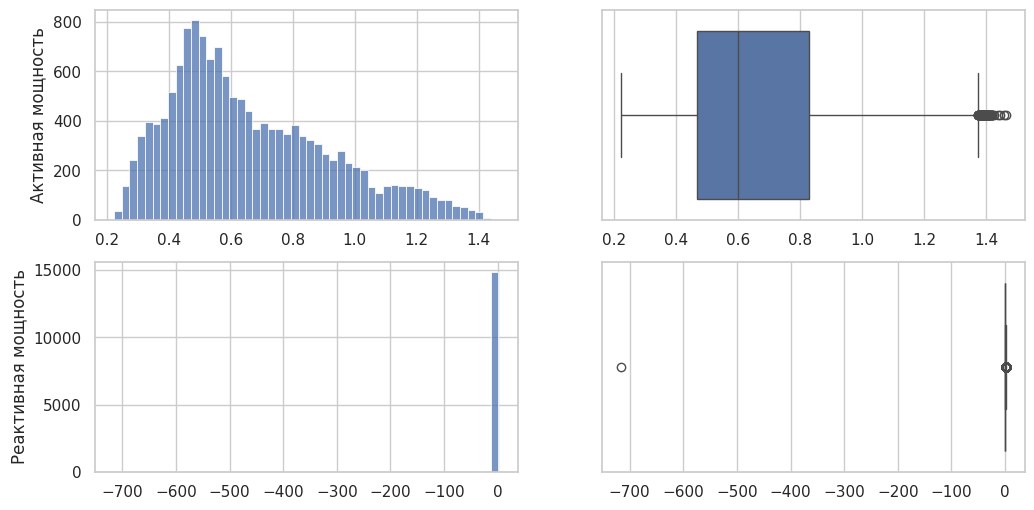

In [7]:
explore_df(data_arc)

- каждая запись - один цикл нагрева ковша с времением начала и конца и параметрами мощности
- по каждому ковшу как правило есть несколько записей - несколько циклов
- аномальный минимум в Реактивной мощности
- пропусков нет
- полных дубликатов нет

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>ок, примерно так. Есть ещё супервыброс в реактивной.

### data_bulk
данные о подаче сыпучих материалов (объём)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
1613,NaN,NaN,NaN,NaN,NaN,106.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,298.0,NaN
1325,NaN,NaN,128.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,419.0,NaN,200.0,217.0
2226,NaN,NaN,38.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,NaN,129.0,156.0
1805,NaN,NaN,NaN,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,101.0,104.0
2845,NaN,NaN,NaN,NaN,NaN,124.0,NaN,NaN,NaN,NaN,NaN,522.0,NaN,228.0,106.0


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Bulk 1   252 non-null    float64
 1   Bulk 2   22 non-null     float64
 2   Bulk 3   1298 non-null   float64
 3   Bulk 4   1014 non-null   float64
 4   Bulk 5   77 non-null     float64
 5   Bulk 6   576 non-null    float64
 6   Bulk 7   25 non-null     float64
 7   Bulk 8   1 non-null      float64
 8   Bulk 9   19 non-null     float64
 9   Bulk 10  176 non-null    float64
 10  Bulk 11  177 non-null    float64
 11  Bulk 12  2450 non-null   float64
 12  Bulk 13  18 non-null     float64
 13  Bulk 14  2806 non-null   float64
 14  Bulk 15  2248 non-null   float64
dtypes: float64(15)
memory usage: 391.1 KB
----------------------------------------------------------------------------------------------------

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 80
----------------------------------------------------------------------------------------------------

unique keys:

3129


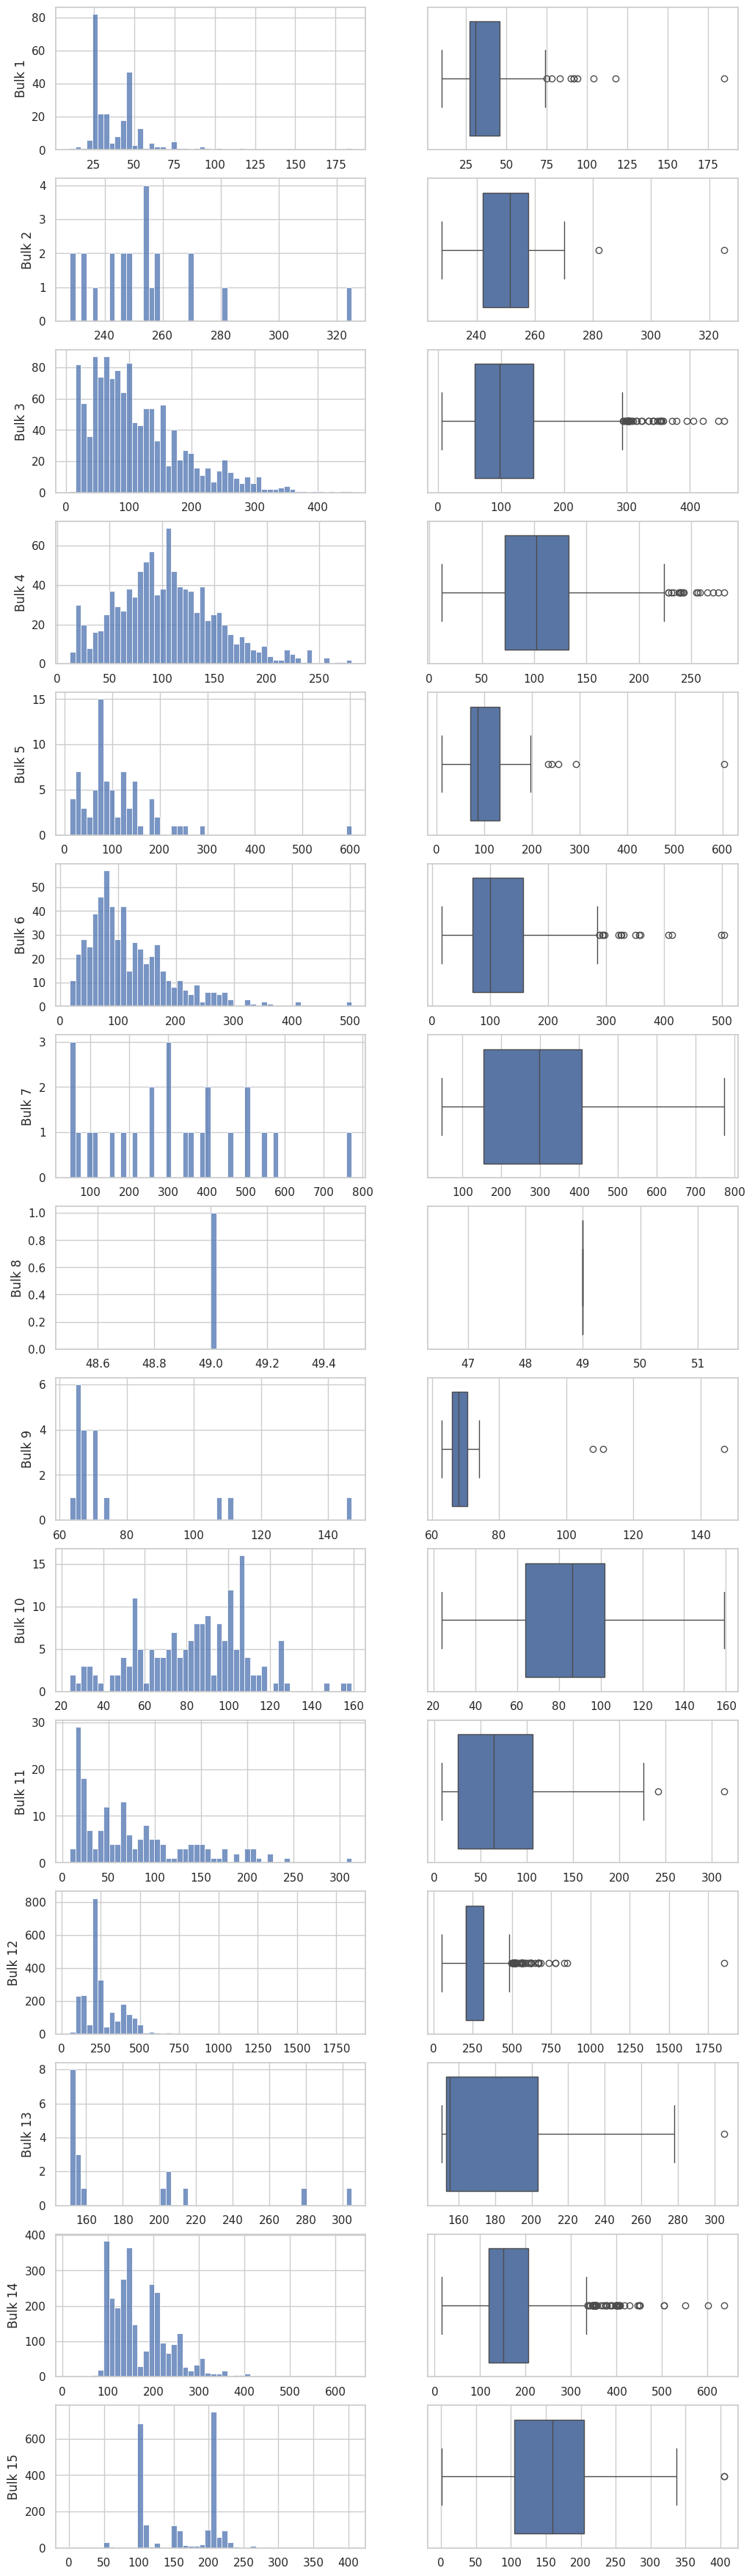

In [8]:
explore_df(data_bulk)

- здесь один ковш - одна запись. колонки по всей видимости соответствуют различным материалам - их поданному в ковш объему
- пропуски видимо значат, что такой материал не применялся, т.е. стоит заменить их на 0
- оценить здесь, что есть выбросы, без дополнительной информации сложно, но явных (отрицательных или огромных, нет)
- дубликатов по ключу нет

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
хорошо, идём дальше.

### data_bulk_time
данные о подаче сыпучих материалов (время)

In [9]:
explore_df(data_bulk_time)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
2684,NaT,NaT,2019-08-17 09:57:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-08-17 09:52:39,NaT
1072,NaT,NaT,2019-06-13 16:53:54,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-06-13 16:53:54,NaT,2019-06-13 16:50:53,2019-06-13 16:43:49
1264,NaT,NaT,NaT,2019-06-20 03:52:16,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-06-20 04:08:59,NaT,2019-06-20 04:03:33,2019-06-20 03:59:06
102,NaT,NaT,2019-05-07 04:36:23,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-07 04:36:23,NaT,2019-05-07 04:36:23,NaT,2019-05-07 04:22:46,2019-05-07 04:08:34
2972,NaT,NaT,2019-08-28 11:11:19,2019-08-28 11:30:54,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-08-28 11:28:16,NaT,2019-08-28 11:23:25,2019-08-28 11:16:35


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Bulk 1   252 non-null    datetime64[ns]
 1   Bulk 2   22 non-null     datetime64[ns]
 2   Bulk 3   1298 non-null   datetime64[ns]
 3   Bulk 4   1014 non-null   datetime64[ns]
 4   Bulk 5   77 non-null     datetime64[ns]
 5   Bulk 6   576 non-null    datetime64[ns]
 6   Bulk 7   25 non-null     datetime64[ns]
 7   Bulk 8   1 non-null      datetime64[ns]
 8   Bulk 9   19 non-null     datetime64[ns]
 9   Bulk 10  176 non-null    datetime64[ns]
 10  Bulk 11  177 non-null    datetime64[ns]
 11  Bulk 12  2450 non-null   datetime64[ns]
 12  Bulk 13  18 non-null     datetime64[ns]
 13  Bulk 14  2806 non-null   datetime64[ns]
 14  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](1

- у data_bulk_time структура такая же, как у data_bulk
- дубликатов по ключу нет

### data_gas
данные о продувке сплава газом

----------------------------------------------------------------------------------------------------
sample:


,Газ 1
key,
1651,18.844898
1214,12.933558
2062,17.271727
1916,18.867788
651,9.909262


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3239 entries, 1 to 3241
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Газ 1   3239 non-null   float64
dtypes: float64(1)
memory usage: 50.6 KB
----------------------------------------------------------------------------------------------------

describe:



,Газ 1
count,3239.000000
mean,11.002062
std,6.220327
min,0.008399
25%,7.043089
50%,9.836267
75%,13.769915
max,77.995040


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3239


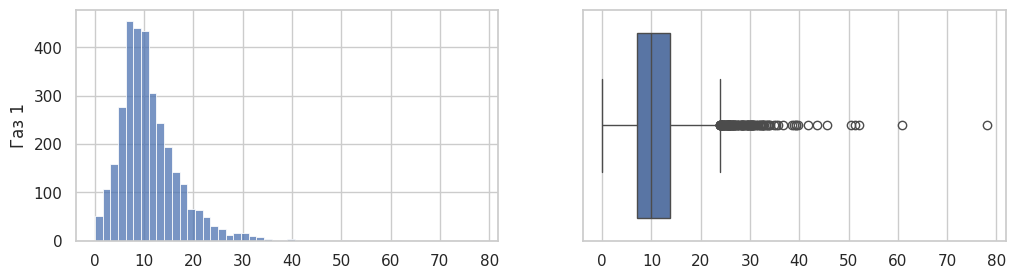

In [10]:
explore_df(data_gas)

- data_gas - просто какой объем газа (видимо, в сумме) был продут через каждый ковш
- дубликатов нет
- лакун нет
- явных выбросов нет

### data_temp
результаты измерения температуры

----------------------------------------------------------------------------------------------------
sample:


,Время замера,Температура
key,,
611,2019-05-26 14:56:34,1602.0
2150,2019-07-29 05:03:23,1589.0
1920,2019-07-19 08:31:45,1584.0
3080,2019-09-01 05:15:41,NaN
1599,2019-07-02 11:15:41,1558.0


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 18092 entries, 1 to 3241
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Время замера  18092 non-null  datetime64[ns]
 1   Температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 424.0 KB
----------------------------------------------------------------------------------------------------

describe:



,Температура
count,14665.000000
mean,1590.722741
std,20.394381
min,1191.000000
25%,1580.000000
50%,1590.000000
75%,1599.000000
max,1705.000000


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 14876, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3216


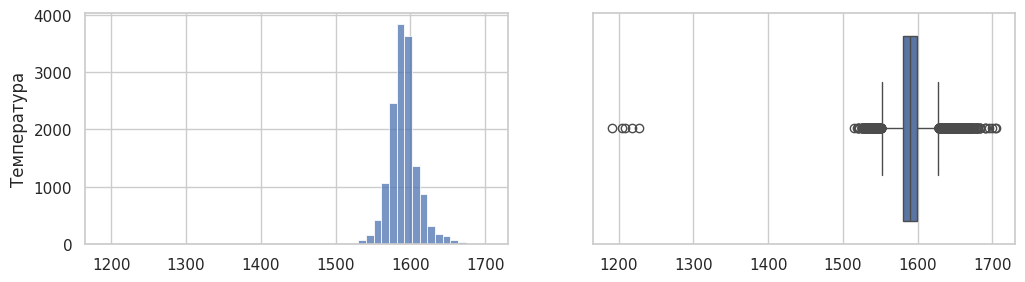

In [11]:
explore_df(data_temp)

- в data_temp каждая запись - один замер (время и температура). как правило по несколько замеров для каждого ковша.
- есть лакуны в поле температуры
- есть значения заведомо ниже температуры плавления сплава (~1400), чего быть не должно - сплав застынет и все - будем считать выбросами
- если не считать выбросы, распределение похоже на нормальное с чуть более вытянутым хвостом в сторону высоких температур

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>Хорошо, тут по делу всё.

### data_wire
данные о проволочных материалах (объём)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
1711,180.273591,15.080000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
301,125.099525,67.238082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1757,74.692803,124.741764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3091,143.052001,NaN,283.242963,NaN,NaN,NaN,NaN,NaN,NaN
1299,241.300813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Wire 1  3055 non-null   float64
 1   Wire 2  1079 non-null   float64
 2   Wire 3  63 non-null     float64
 3   Wire 4  14 non-null     float64
 4   Wire 5  1 non-null      float64
 5   Wire 6  73 non-null     float64
 6   Wire 7  11 non-null     float64
 7   Wire 8  19 non-null     float64
 8   Wire 9  29 non-null     float64
dtypes: float64(9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:



,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 403
----------------------------------------------------------------------------------------------------

unique keys:

3081


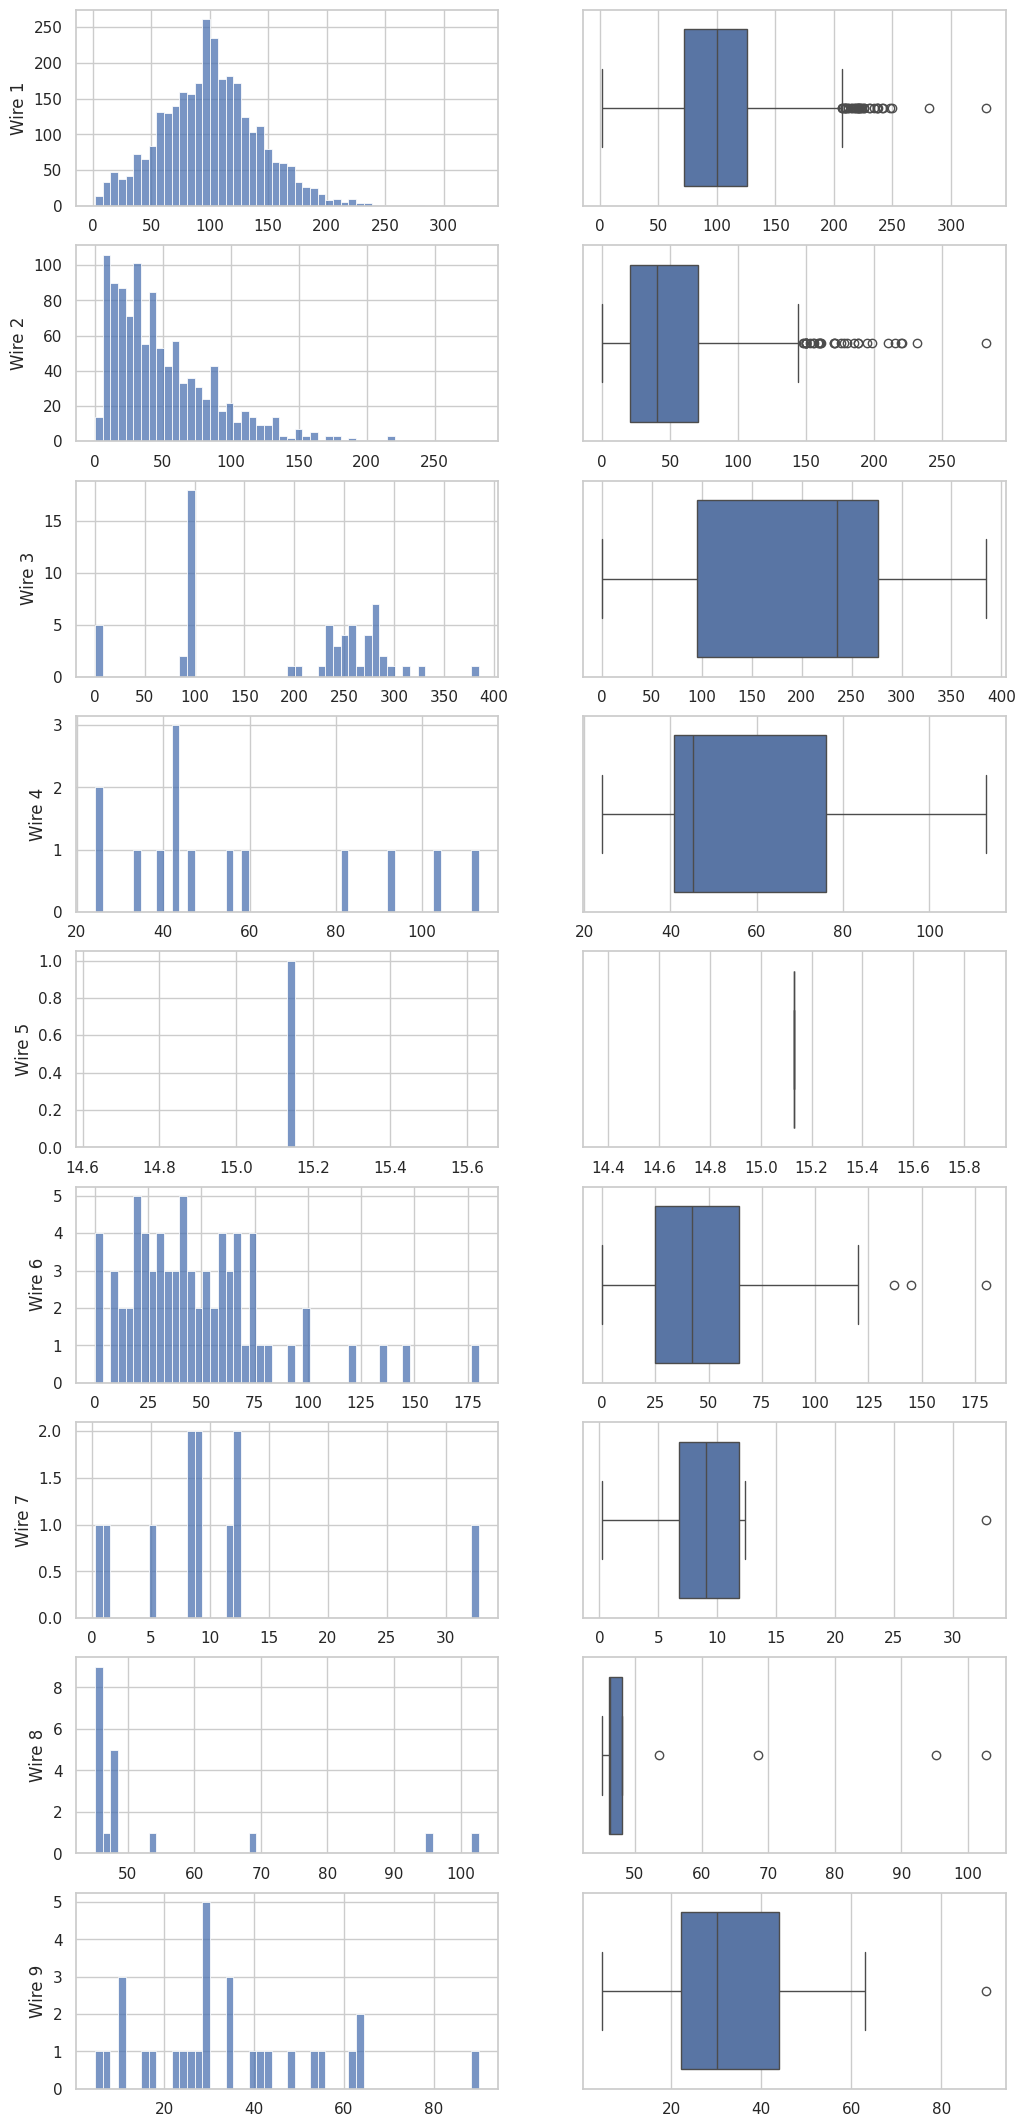

In [12]:
explore_df(data_wire)

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов
- дубликатов по ключу нет

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>ок. Можно ещё оставлять выводы по типу распределения.

### data_wire_time
данные о проволочных материалах (время)

In [13]:
explore_df(data_wire_time)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
2384,2019-08-06 12:31:18,2019-08-06 12:21:40,NaT,NaT,NaT,NaT,NaT,NaT,NaT
649,2019-05-28 17:10:12,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2646,2019-08-16 02:33:37,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
582,2019-05-25 12:44:54,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1960,2019-07-21 18:29:58,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Wire 1  3055 non-null   datetime64[ns]
 1   Wire 2  1079 non-null   datetime64[ns]
 2   Wire 3  63 non-null     datetime64[ns]
 3   Wire 4  14 non-null     datetime64[ns]
 4   Wire 5  1 non-null      datetime64[ns]
 5   Wire 6  73 non-null     datetime64[ns]
 6   Wire 7  11 non-null     datetime64[ns]
 7   Wire 8  19 non-null     datetime64[ns]
 8   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:

----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row du

- data_wire_time - то же самое, что для data_wire

### Общие выводы по данным
- Есть две очевидные аномалии:
  - очень низкое значение в реактивной мощности
  - есть значения заведомо ниже температуры плавления сплава (~1400)
- Пропуски для bulk и wire надо заменить нулями
- Характер распределений здесь кроме температуры, наверное, описывать смысла нет, т.к. он определяется технологией процесса
- Желательно переименовать колонки в общепринятом стиле
- Хорошо бы найти метод определить время начала работы с ковшом, тогда можно попробовать перевести все времена для ковша в относительные к времени начала
- Для нагрева электродами можно посчитать продолжительность цикла и работу (активная мощность * продолжительность)
- Реактивная мощность по идее не должна влиять на температуру. Только на затраты энергии
- Дубликатов, которые надо убрать, как будто нет

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>Первый раздел сделан как надо: и аналитика, и графика, и выводы. С идеями - ниже посмотрим реализацию, такт-то все они рабочие.

## Предобработка данных
### Переименования колонок

In [14]:
data_arc.columns = ['arc_start_time', 'arc_end_time', 'arc_active_power', 'arc_reactive_power']
data_bulk.columns = [f'bulk_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_bulk_time.columns = [f'bulk_time_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_gas.columns = ['gas_1']
data_temp.columns = ['temp_time', 'temp']
data_wire.columns = [f'wire_{x:02}' for x in range(1, data_wire.shape[1] + 1)]
data_wire_time.columns = [f'wire_time_{x:02}' for x in range(1, data_wire.shape[1] + 1)]

for df in [data_arc, data_bulk, data_bulk_time, data_gas, data_temp, data_wire, data_wire_time]:
	print(df.columns)

Index(['arc_start_time', 'arc_end_time', 'arc_active_power',
       'arc_reactive_power'],
      dtype='object')
Index(['bulk_01', 'bulk_02', 'bulk_03', 'bulk_04', 'bulk_05', 'bulk_06',
       'bulk_07', 'bulk_08', 'bulk_09', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')
Index(['bulk_time_01', 'bulk_time_02', 'bulk_time_03', 'bulk_time_04',
       'bulk_time_05', 'bulk_time_06', 'bulk_time_07', 'bulk_time_08',
       'bulk_time_09', 'bulk_time_10', 'bulk_time_11', 'bulk_time_12',
       'bulk_time_13', 'bulk_time_14', 'bulk_time_15'],
      dtype='object')
Index(['gas_1'], dtype='object')
Index(['temp_time', 'temp'], dtype='object')
Index(['wire_01', 'wire_02', 'wire_03', 'wire_04', 'wire_05', 'wire_06',
       'wire_07', 'wire_08', 'wire_09'],
      dtype='object')
Index(['wire_time_01', 'wire_time_02', 'wire_time_03', 'wire_time_04',
       'wire_time_05', 'wire_time_06', 'wire_time_07', 'wire_time_08',
       'wire_time_09'],
      d

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>порядок)

### Убираем аномалии
- очень низкое значение в реактивной мощности
- значения заведомо ниже температуры плавления сплава (~1400)

,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power
key,,,,
2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


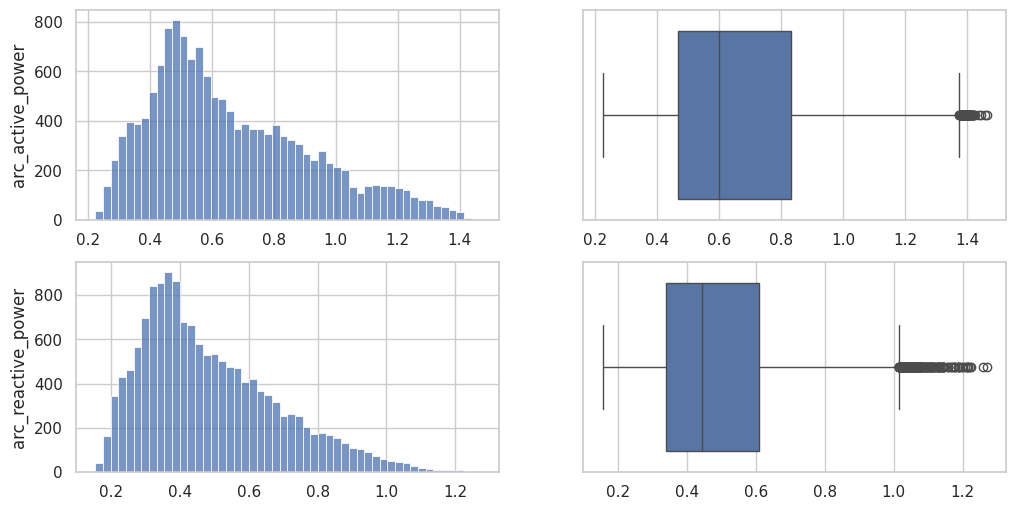

In [15]:
display(data_arc.query('arc_reactive_power < 0'))
data_arc.drop(index=data_arc.query('arc_reactive_power < 0').index, inplace=True)
plot_num_cont(data_arc)

,temp_time,temp
key,,
867,2019-06-06 08:03:39,1191.0
1214,2019-06-18 08:01:03,1208.0
1619,2019-07-03 02:34:41,1218.0
2052,2019-07-25 08:49:15,1227.0
2561,2019-08-12 18:49:29,1204.0


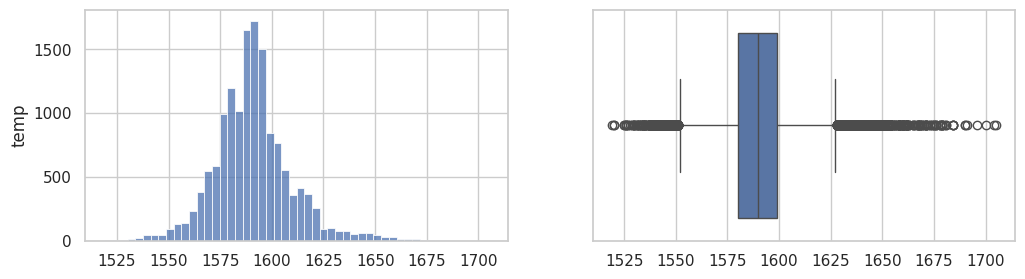

In [16]:
display(data_temp.query('temp < 1400'))
data_temp.drop(index=data_temp.query('temp < 1400').index, inplace=True)
plot_num_cont(data_temp)

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>верно, удалять надо именно объект моделирования, ОК.

### Заменяем пропуски на нули
Там, где это приемлемо: bulk и wire

In [17]:
data_bulk.fillna(value=0, inplace=True)
data_wire.fillna(value=0, inplace=True)
print(data_bulk.isna().sum().sum())
print(data_wire.isna().sum().sum())

0
0


<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>согласен

### Удаляем пропуски
В data_temp есть пропуски температуры. Измерений для каждого ковша несколько. Конечная температура - таргет, начальная - входные данные. Наверное, пока лучше просто удалить пропущенные значения, *а после объединения удалить целиком ковши, у которых нет начальной или конечной температуры*.

In [18]:
data_temp.dropna(inplace=True)
print(data_temp.isna().sum().sum())

0


In [19]:
data_temp

,temp_time,temp
key,,
1,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:18:04,1601.0
1,2019-05-03 11:25:59,1606.0
...,...,...
3237,2019-09-06 11:31:15,1569.0
3238,2019-09-06 12:16:15,1584.0
3239,2019-09-06 14:16:50,1598.0


<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>А вот тут надо также, как выше - работать именно с объектами моделирования. Есть ковши, в которых нет целевой. И принято решение удалять - надо удалять Весь объект, Т.Е. КОВШ. Но посомтрим далее, что будет.

<div class="alert alert-info"><b>Комментарии студента</b><br>Пока добавил коммент "после объединения удалить целиком ковши, у которых нет начальной или конечной температуры". Ниже это выполним</div>

### Новые признаки в arc
В data_arc надо посчитать работу по нагреву. Т.к. именно от кол-ва джоулей зависит насколько изменится температура.

Для расчета работы возьмем только acive_power, без reacive_power. Т.к."тратится", и соотв. передает энергию только активная составляющая (ну почти только она - реактивная мощность вроде как тоже создает ток, который в среде, обладающей сопротивлением, теряет какую-то часть энергии в тепло, но это не точно).

Длительность нагрева выделим в отдельное поле.

Еще на всякий случай посчитаем полную (кажущуюся) мощность (корень суммы квадратов двух мощностей), и посмотрим, как ее влияение на температуру оценит модель.

In [20]:
data_arc.loc[:, 'arc_duration_sec'] = (data_arc['arc_end_time'] - data_arc['arc_start_time']).dt.seconds
data_arc.loc[:, 'arc_work'] = data_arc['arc_duration_sec'] * data_arc['arc_active_power']
data_arc[['arc_duration_sec', 'arc_active_power', 'arc_work']].sample(3)

,arc_duration_sec,arc_active_power,arc_work
key,,,
423,327,0.666041,217.795407
750,122,0.782959,95.520998
2068,81,0.425311,34.450191


In [21]:
data_arc.loc[:, 'arc_apparent_power'] = (data_arc['arc_active_power'] ** 2 + data_arc['arc_reactive_power'] ** 2) ** .5
data_arc['arc_apparent_power'].sample(3)

key
1741    0.686379
1594    1.209752
692     1.277516
Name: arc_apparent_power, dtype: float64

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>Новый факторы нам не помешают, принято.

### Объединение данных
~~Попробуем такой подход: у нас для каждого ковша есть несколько измерений температуры в определенные моменты времени и есть данные по действиям, которые совершали над этим ковшом, тоже с указанием моментов времени. Можно сделать такие обучающие записи: предыдущая температура, результирующая температура, все действия, которые были произведены в промежуток времени между этими двумя измерениями температур.~~

~~Здесь, правда, есть теоретическая сложность: если время измерения температуры будет попадать в интервал нагрева, то работу по нагреву придется распределять по двум интервалам температур. Но по идее такого быть не должно: нагревали и измеряли, как будто не одновременно. Посмотрим.~~

*У нас для каждого ковша есть несколько измерений температуры в определенные моменты времени и есть данные по действиям, которые совершали над этим ковшом, тоже с указанием моментов времени. Можно сделать такие обучающие записи: первая температура, конечная температура, все действия, которые были произведены в промежуток времени между этими двумя измерениями температур.*

Набор со всеми собранными данными будет называться *data_all*

#### Начальная и конечная температура в ковше
Трансформируем данные с температурами в записи первым и последним измерением температуры.

<div class="alert alert-danger" style="border-color: darkred; border-radius: 5px">
    <p><u><b>❌ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>
Дело в том, что наша целевая - последняя по партии, т.е. температура розлива. Фактором можно взять - начальное состояние объекта - первую температуру. В общем-то, и  всё. Остальные температуры однозначно "накрутят" хорошую метрику. НО с позиции практики такая модель не интересная, т.е. ценность нулевая. Т.к., если включать фактором предыдущие температуры. то это означает, что при работе модели в боюнам надо будет предсказывать эту самую предпоследнюю температуру. Т.е. ещё одну такую же модель делать. Не удобно. Поэтому, и не стоит их использовать.    
</p>
</div>

<div class="alert alert-info"><b>Комментарии студента</b><br>Понял. Пойдем другим путем. Спасибо</div>

In [22]:
data_all = data_temp.reset_index().sort_values(by=['key', 'temp_time'])

data_all_first = data_all.loc[data_all.groupby(by='key')['temp_time'].idxmin()]
data_all_last = data_all.loc[data_all.groupby(by='key')['temp_time'].idxmax()]
data_all_first.set_index('key', inplace=True)
data_all_last.set_index('key', inplace=True)

data_all = data_all_first.merge(data_all_last, how='inner', left_index=True, right_index=True, suffixes=('_first', '_last'))

data_all.sort_values(by=['key'], inplace=True)
data_all.dropna(inplace=True)

print('before:', data_temp.shape)
display(data_temp.head(15))
print('after:', data_all.shape)
display(data_all.head(15))


before: (14643, 2)


,temp_time,temp
key,,
1,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:18:04,1601.0
1,2019-05-03 11:25:59,1606.0
1,2019-05-03 11:30:38,1613.0
2,2019-05-03 11:34:04,1581.0
2,2019-05-03 11:38:40,1577.0
2,2019-05-03 11:46:09,1589.0


after: (3211, 4)


,temp_time_first,temp_first,temp_time_last,temp_last
key,,,,
1,2019-05-03 11:02:04,1571.0,2019-05-03 11:30:38,1613.0
2,2019-05-03 11:34:04,1581.0,2019-05-03 11:55:09,1602.0
3,2019-05-03 12:06:44,1596.0,2019-05-03 12:35:57,1599.0
4,2019-05-03 12:39:27,1601.0,2019-05-03 12:59:47,1625.0
5,2019-05-03 13:11:03,1576.0,2019-05-03 13:36:39,1602.0
6,2019-05-03 13:46:41,1543.0,2019-05-03 14:11:38,1596.0
7,2019-05-03 14:16:36,1586.0,2019-05-03 14:45:40,1599.0
8,2019-05-03 14:53:46,1577.0,2019-05-03 15:20:41,1598.0
9,2019-05-03 15:36:33,1587.0,2019-05-03 16:06:44,1592.0


Добавим поле - временной интервал между измерениями в секундах

In [23]:
data_all.loc[:, 'temp_interval_sec'] = (data_all['temp_time_last'] - data_all['temp_time_first']).dt.seconds

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Длительность нагрева по объекту моделтированию - в целом нужный фактор. но лучше его не этих таблицах считать) На изначальных</p>
</div>

#### temp_delta
~~Добавим поле - изменение температуры. Попробуем использовать его как таргет. Идея в том, что модели может быть естественнее посчитать изменение температуры, чем саму ее.~~ (Спойлер - на самом деле как будто все-равно, модели, имея предыдущую температуру, примерно так же справляются с вычислением следующей, как и с дельтой).

In [24]:
#data_all.loc[:, 'temp_delta'] = data_all['temp_last'] - data_all['temp_first']

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Как вариант - можно попробовать и так. Но рассуждения в терминах "начальное состояние объекта - первая температура, и температура розлива - последняя температура по объекту (ковшу) кажется логичнее звучит. По крайней мре бизнесу будет точно понятно) Но решение - за аналитиком. Если так, то в конце надо не забывать переводить дельту - в конечную температуру. Заказчику именно она и нужна.</p>
</div>

#### Добавляем arc
Сначала просто сольем суммарный нагрев с записями про температуру по номеру ковша

In [25]:
data_arc

,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,
1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228,69.569640,0.371123
1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185,141.646730,0.902319
1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172,99.813836,0.722536
1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365,189.251040,0.642824
1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148,128.335684,1.079934
...,...,...,...,...,...,...,...
3241,2019-09-06 16:49:05,2019-09-06 16:51:42,0.439735,0.299579,157,69.038395,0.532085
3241,2019-09-06 16:55:11,2019-09-06 16:58:11,0.646498,0.458240,180,116.369640,0.792429
3241,2019-09-06 17:06:48,2019-09-06 17:09:52,1.039726,0.769302,184,191.309584,1.293389


In [26]:
data_arc_agg = data_arc.reset_index().groupby(by='key').agg({
	'arc_start_time': 'min',
	'arc_end_time': 'max',
	'arc_active_power': 'sum',
	'arc_reactive_power': 'sum',
	'arc_duration_sec': 'sum',
	'arc_work': 'sum',
	'arc_apparent_power': 'sum',
})
data_all_raw = data_all.merge(data_arc_agg, how='left', left_index=True, right_index=True, suffixes=('', ''))
del data_arc_agg
data_all_raw

,temp_time_first,temp_first,temp_time_last,temp_last,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,
1,2019-05-03 11:02:04,1571.0,2019-05-03 11:30:38,1613.0,1714,2019-05-03 11:02:14,2019-05-03 11:28:37,3.036730,2.142821,1098.0,628.616930,3.718736
2,2019-05-03 11:34:04,1581.0,2019-05-03 11:55:09,1602.0,1265,2019-05-03 11:34:14,2019-05-03 11:53:18,2.139408,1.453357,811.0,395.281800,2.588349
3,2019-05-03 12:06:44,1596.0,2019-05-03 12:35:57,1599.0,1753,2019-05-03 12:06:54,2019-05-03 12:32:19,4.063641,2.937457,655.0,581.774624,5.019223
4,2019-05-03 12:39:27,1601.0,2019-05-03 12:59:47,1625.0,1220,2019-05-03 12:39:37,2019-05-03 12:57:50,2.706489,2.056992,741.0,543.710274,3.400038
5,2019-05-03 13:11:03,1576.0,2019-05-03 13:36:39,1602.0,1536,2019-05-03 13:11:13,2019-05-03 13:33:55,2.252950,1.687991,869.0,412.180480,2.816980
...,...,...,...,...,...,...,...,...,...,...,...,...
3237,2019-09-06 11:31:15,1569.0,2019-09-06 11:31:15,1569.0,0,2019-09-06 11:31:25,2019-09-06 11:53:55,2.541872,2.025417,909.0,493.152191,3.250657
3238,2019-09-06 12:16:15,1584.0,2019-09-06 12:16:15,1584.0,0,2019-09-06 12:16:25,2019-09-06 12:31:35,1.374821,1.038103,546.0,229.390861,1.723937
3239,2019-09-06 14:16:50,1598.0,2019-09-06 14:16:50,1598.0,0,2019-09-06 14:17:00,2019-09-06 15:05:50,4.848005,3.541541,1216.0,751.674870,6.014480


In [27]:
data_all_raw.query(
	'arc_start_time < temp_time_first or arc_end_time > temp_time_last'
)

,temp_time_first,temp_first,temp_time_last,temp_last,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,
2500,2019-08-10 14:04:39,1539.0,2019-08-10 14:04:39,1539.0,0,2019-08-10 14:04:49,2019-08-10 14:27:00,2.254893,1.596034,854.0,524.344565,2.764368
2501,2019-08-10 14:41:14,1587.0,2019-08-10 14:41:14,1587.0,0,2019-08-10 14:41:24,2019-08-10 15:23:47,3.652121,2.707299,978.0,619.749475,4.551705
2502,2019-08-10 15:39:39,1583.0,2019-08-10 15:39:39,1583.0,0,2019-08-10 15:39:49,2019-08-10 16:00:54,3.895010,2.924756,543.0,560.674346,4.873812
2503,2019-08-10 16:27:44,1603.0,2019-08-10 16:27:44,1603.0,0,2019-08-10 16:27:54,2019-08-10 17:05:20,2.173770,1.655701,613.0,331.439883,2.738596
2504,2019-08-10 17:31:43,1583.0,2019-08-10 17:31:43,1583.0,0,2019-08-10 17:31:53,2019-08-10 18:00:04,3.238420,2.116856,819.0,537.851426,3.870843
...,...,...,...,...,...,...,...,...,...,...,...,...
3237,2019-09-06 11:31:15,1569.0,2019-09-06 11:31:15,1569.0,0,2019-09-06 11:31:25,2019-09-06 11:53:55,2.541872,2.025417,909.0,493.152191,3.250657
3238,2019-09-06 12:16:15,1584.0,2019-09-06 12:16:15,1584.0,0,2019-09-06 12:16:25,2019-09-06 12:31:35,1.374821,1.038103,546.0,229.390861,1.723937
3239,2019-09-06 14:16:50,1598.0,2019-09-06 14:16:50,1598.0,0,2019-09-06 14:17:00,2019-09-06 15:05:50,4.848005,3.541541,1216.0,751.674870,6.014480


Теперь оставим только те, где нагрев был, и его время не выпадает из интервала между измерениями температуры

In [28]:
data_all = data_all_raw.query('arc_start_time >= temp_time_first and arc_end_time <= temp_time_last')
display(data_all.sample(5))
data_all.shape

,temp_time_first,temp_first,temp_time_last,temp_last,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,
740,2019-06-01 09:02:06,1596.0,2019-06-01 09:31:26,1593.0,1760,2019-06-01 09:02:16,2019-06-01 09:26:47,2.630928,1.937166,634.0,451.844773,3.272903
2261,2019-08-01 20:32:24,1574.0,2019-08-01 21:02:35,1597.0,1811,2019-08-01 20:32:34,2019-08-01 21:00:07,4.484464,3.103681,1063.0,922.641228,5.459033
1563,2019-07-01 05:52:02,1628.0,2019-07-01 06:15:51,1653.0,1429,2019-07-01 05:52:12,2019-07-01 06:13:09,1.395872,0.970456,932.0,450.030582,1.700442
1659,2019-07-04 08:29:24,1572.0,2019-07-04 08:52:03,1585.0,1359,2019-07-04 08:29:34,2019-07-04 08:48:15,1.540410,1.128603,665.0,336.598242,1.913532
1018,2019-06-11 18:07:43,1561.0,2019-06-11 18:32:16,1589.0,1473,2019-06-11 18:07:53,2019-06-11 18:29:41,2.148155,1.535055,843.0,480.331148,2.640987


(2470, 12)

<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Если рассуждать объектом моелирования, то тут так: Есть объекты (ковши) в которых нет последней температуры, т.е. нет целевой. А это значит что сам объект - не совсем качественный для работы. Значит удаляем такой объект. </p>
</div>

<div class="alert alert-info"><b>Комментарии студента</b><br>Кажется, поправил</div>

Значит temp и arc собрали вместе

#### Добавляем bulk
Сначала просто соберем поля вместе

In [29]:
data_all_raw = data_all.\
	merge(data_bulk, how='left', left_index=True, right_index=True, suffixes=('', '')).\
	merge(data_bulk_time, how='left', left_index=True, right_index=True, suffixes=('', ''))
display(data_all_raw.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2470 entries, 1 to 2499
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   temp_time_first     2470 non-null   datetime64[ns]
 1   temp_first          2470 non-null   float64       
 2   temp_time_last      2470 non-null   datetime64[ns]
 3   temp_last           2470 non-null   float64       
 4   temp_interval_sec   2470 non-null   int32         
 5   arc_start_time      2470 non-null   datetime64[ns]
 6   arc_end_time        2470 non-null   datetime64[ns]
 7   arc_active_power    2470 non-null   float64       
 8   arc_reactive_power  2470 non-null   float64       
 9   arc_duration_sec    2470 non-null   float64       
 10  arc_work            2470 non-null   float64       
 11  arc_apparent_power  2470 non-null   float64       
 12  bulk_01             2402 non-null   float64       
 13  bulk_02             2402 non-null   float64       
 1

None

Теперь почистим те bulk, время внесения которых не попадает в интервал между измерениями температуры

In [30]:
def clear_by_additives(df, additives_cols):
	return df[
			(df['temp_time_first'] <= df[additives_cols].min(axis=1)) &
			(df['temp_time_last'] >= df[additives_cols].max(axis=1))
	]

data_all = clear_by_additives(data_all_raw, data_bulk_time.columns.to_list())

print(data_all.shape)
display(data_all.head(5))

(2402, 42)


,temp_time_first,temp_first,temp_time_last,temp_last,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_08,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,bulk_time_01,bulk_time_02,bulk_time_03,bulk_time_04,bulk_time_05,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15
key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:02:04,1571.0,2019-05-03 11:30:38,1613.0,1714,2019-05-03 11:02:14,2019-05-03 11:28:37,3.036730,2.142821,1098.0,628.616930,3.718736,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
2,2019-05-03 11:34:04,1581.0,2019-05-03 11:55:09,1602.0,1265,2019-05-03 11:34:14,2019-05-03 11:53:18,2.139408,1.453357,811.0,395.281800,2.588349,0.0,0.0,0.0,73.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,149.0,154.0,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39
3,2019-05-03 12:06:44,1596.0,2019-05-03 12:35:57,1599.0,1753,2019-05-03 12:06:54,2019-05-03 12:32:19,4.063641,2.937457,655.0,581.774624,5.019223,0.0,0.0,0.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,205.0,0.0,152.0,153.0,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16
4,2019-05-03 12:39:27,1601.0,2019-05-03 12:59:47,1625.0,1220,2019-05-03 12:39:37,2019-05-03 12:57:50,2.706489,2.056992,741.0,543.710274,3.400038,0.0,0.0,0.0,81.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,207.0,0.0,153.0,154.0,NaT,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,NaT,2019-05-03 12:51:11,2019-05-03 12:46:36
5,2019-05-03 13:11:03,1576.0,2019-05-03 13:36:39,1602.0,1536,2019-05-03 13:11:13,2019-05-03 13:33:55,2.252950,1.687991,869.0,412.180480,2.816980,0.0,0.0,0.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,203.0,0.0,151.0,152.0,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,2019-05-03 13:34:12,2019-05-03 13:30:47


#### Добавляем wire
По такой же схеме, как bulk

In [31]:
data_all_raw = data_all.\
	merge(data_wire, how='left', left_index=True, right_index=True, suffixes=('', '')).\
	merge(data_wire_time, how='left', left_index=True, right_index=True, suffixes=('', ''))
display(data_all_raw.info())

data_all = clear_by_additives(data_all_raw, data_wire_time.columns.to_list())

print(data_all.shape)
display(data_all.head(5))

<class 'pandas.core.frame.DataFrame'>
Index: 2402 entries, 1 to 2499
Data columns (total 60 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   temp_time_first     2402 non-null   datetime64[ns]
 1   temp_first          2402 non-null   float64       
 2   temp_time_last      2402 non-null   datetime64[ns]
 3   temp_last           2402 non-null   float64       
 4   temp_interval_sec   2402 non-null   int32         
 5   arc_start_time      2402 non-null   datetime64[ns]
 6   arc_end_time        2402 non-null   datetime64[ns]
 7   arc_active_power    2402 non-null   float64       
 8   arc_reactive_power  2402 non-null   float64       
 9   arc_duration_sec    2402 non-null   float64       
 10  arc_work            2402 non-null   float64       
 11  arc_apparent_power  2402 non-null   float64       
 12  bulk_01             2402 non-null   float64       
 13  bulk_02             2402 non-null   float64       
 1

None

(2326, 60)


,temp_time_first,temp_first,temp_time_last,temp_last,temp_interval_sec,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_08,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,bulk_time_01,bulk_time_02,bulk_time_03,bulk_time_04,bulk_time_05,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15,wire_01,wire_02,wire_03,wire_04,wire_05,wire_06,wire_07,wire_08,wire_09,wire_time_01,wire_time_02,wire_time_03,wire_time_04,wire_time_05,wire_time_06,wire_time_07,wire_time_08,wire_time_09
key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:02:04,1571.0,2019-05-03 11:30:38,1613.0,1714,2019-05-03 11:02:14,2019-05-03 11:28:37,3.036730,2.142821,1098.0,628.616930,3.718736,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,2019-05-03 11:34:04,1581.0,2019-05-03 11:55:09,1602.0,1265,2019-05-03 11:34:14,2019-05-03 11:53:18,2.139408,1.453357,811.0,395.281800,2.588349,0.0,0.0,0.0,73.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,149.0,154.0,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
3,2019-05-03 12:06:44,1596.0,2019-05-03 12:35:57,1599.0,1753,2019-05-03 12:06:54,2019-05-03 12:32:19,4.063641,2.937457,655.0,581.774624,5.019223,0.0,0.0,0.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,205.0,0.0,152.0,153.0,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 12:11:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
4,2019-05-03 12:39:27,1601.0,2019-05-03 12:59:47,1625.0,1220,2019-05-03 12:39:37,2019-05-03 12:57:50,2.706489,2.056992,741.0,543.710274,3.400038,0.0,0.0,0.0,81.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,207.0,0.0,153.0,154.0,NaT,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,NaT,2019-05-03 12:51:11,2019-05-03 12:46:36,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
5,2019-05-03 13:11:03,1576.0,2019-05-03 13:36:39,1602.0,1536,2019-05-03 13:11:13,2019-05-03 13:33:55,2.252950,1.687991,869.0,412.180480,2.816980,0.0,0.0,0.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,203.0,0.0,151.0,152.0,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,2019-05-03 13:34:12,2019-05-03 13:30:47,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT


#### Добавляем gas
Здесь простой мерж

In [32]:
data_gas.head()

,gas_1
key,
1,29.749986
2,12.555561
3,28.554793
4,18.841219
5,5.413692


In [33]:
data_all = data_all.merge(data_gas, how='inner', left_index=True, right_index=True, suffixes=('', ''))

In [34]:
data_all.shape

(2324, 61)

#### Только ключи, которые есть во всех таблицах
У нас есть условие: использовать только те ключи, которые есть во всех таблицах. Т.е. надо проверить, не осталось ли после мержа лакун, допустим, в arc_active_power, bulk_01, wire_01, gas

In [35]:
fields_to_check = ['arc_active_power', 'bulk_01', 'wire_01', 'gas_1']
for fld in fields_to_check:
	print(f'nans in {fld}: {data_all[fld].isna().sum()}')


nans in arc_active_power: 0
nans in bulk_01: 0
nans in wire_01: 0
nans in gas_1: 0


Получается, таких нет

#### Убираем все времена
Мы расставили все события по времени, теперь поля со всеми временами можно убрать

In [36]:
data_all_times = data_all
data_all.drop(columns=data_all.select_dtypes(include='datetime64[ns]').columns, inplace=True)

- Как будто на этом объединение, группировка данных и создание фич закончено

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>календарное время точно не нужно.</p>
</div>

## Исследовательский анализ объединённого датафрейма
Временно заменим все нули на nan. Так будет лучше видно ненулевые значения

In [37]:
data_all_nans = data_all.replace(0., np.nan)

In [38]:
display(data_all_nans.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2324 entries, 1 to 2499
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp_first          2324 non-null   float64
 1   temp_last           2324 non-null   float64
 2   temp_interval_sec   2324 non-null   int32  
 3   arc_active_power    2324 non-null   float64
 4   arc_reactive_power  2324 non-null   float64
 5   arc_duration_sec    2324 non-null   float64
 6   arc_work            2324 non-null   float64
 7   arc_apparent_power  2324 non-null   float64
 8   bulk_01             199 non-null    float64
 9   bulk_02             13 non-null     float64
 10  bulk_03             958 non-null    float64
 11  bulk_04             811 non-null    float64
 12  bulk_05             53 non-null     float64
 13  bulk_06             437 non-null    float64
 14  bulk_07             13 non-null     float64
 15  bulk_08             1 non-null      float64
 16  bulk_09    

None

wire_05 оказался пустым, а у bulk_08 очень мало значений. уберем

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>согласен</p>
</div>

In [39]:
try:
	data_all_nans.drop(columns=['bulk_08', 'wire_05'], inplace=True)
except:
	pass

try:
	data_all.drop(columns=['bulk_08', 'wire_05'], inplace=True)
except:
	pass

In [40]:
display(data_all_nans.describe())

,temp_first,temp_last,temp_interval_sec,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_04,wire_06,wire_07,wire_08,wire_09,gas_1
count,2324.000000,2324.000000,2324.000000,2324.000000,2324.000000,2324.000000,2324.000000,2324.000000,199.000000,13.000000,958.000000,811.000000,53.000000,437.000000,13.000000,13.000000,143.000000,130.000000,1809.000000,14.000000,2064.000000,1696.000000,2301.000000,809.000000,39.000000,12.000000,45.000000,4.000000,13.000000,24.000000,2324.000000
mean,1587.368761,1593.372633,2323.682014,3.126327,2.301280,808.196644,539.381127,3.886143,40.115578,254.846154,114.786013,107.023428,116.018868,119.228833,359.153846,79.692308,82.293706,76.053846,267.982863,177.571429,173.345930,164.541274,103.447694,50.597164,193.182538,59.496235,50.659374,3.703414,55.772561,30.773167,11.378854
std,23.627590,11.207457,1385.809791,1.220484,0.903711,340.813828,257.301093,1.517584,18.226180,25.973853,77.383675,49.074553,95.189182,70.823937,208.804472,25.795299,27.788900,60.373554,125.667744,50.344527,64.028044,50.015721,42.530219,39.800935,100.867783,30.804638,37.743040,3.818433,20.235591,15.210141,6.397008
min,1519.000000,1541.000000,339.000000,0.267676,0.196228,57.000000,26.187544,0.331897,10.000000,228.000000,6.000000,13.000000,11.000000,17.000000,75.000000,63.000000,24.000000,8.000000,53.000000,151.000000,29.000000,1.000000,1.918800,0.030160,0.144144,24.148801,0.137280,0.234208,45.076721,4.622800,0.008399
25%,1571.000000,1587.000000,1580.500000,2.295960,1.671099,581.000000,368.304687,2.846893,27.000000,242.000000,57.250000,73.000000,70.000000,72.000000,178.000000,66.000000,58.000000,25.000000,204.000000,153.250000,123.000000,105.000000,75.042236,20.180161,93.189102,38.347402,25.053600,0.849004,46.002319,20.802601,7.282534
50%,1587.000000,1593.000000,2046.500000,3.036517,2.225900,778.000000,508.538758,3.770584,33.000000,248.000000,96.500000,105.000000,88.000000,100.000000,392.000000,68.000000,85.000000,60.000000,208.000000,154.500000,153.000000,200.000000,102.036476,40.112801,236.972740,49.661561,40.085762,3.044704,46.187439,30.066399,10.100687
75%,1603.000000,1598.000000,2793.500000,3.834302,2.829179,993.000000,679.198659,4.769753,46.500000,258.000000,152.000000,136.500000,148.000000,156.000000,507.000000,71.000000,104.000000,105.500000,360.000000,158.500000,208.000000,205.000000,128.185211,70.061684,277.068801,84.755579,65.036400,5.899114,46.279999,40.495001,14.218487
max,1660.000000,1653.000000,23674.000000,12.375636,8.949049,4189.000000,3718.054401,15.288271,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000,330.314424,282.780152,385.008668,113.231044,180.454575,8.490040,102.762401,62.025600,77.995040


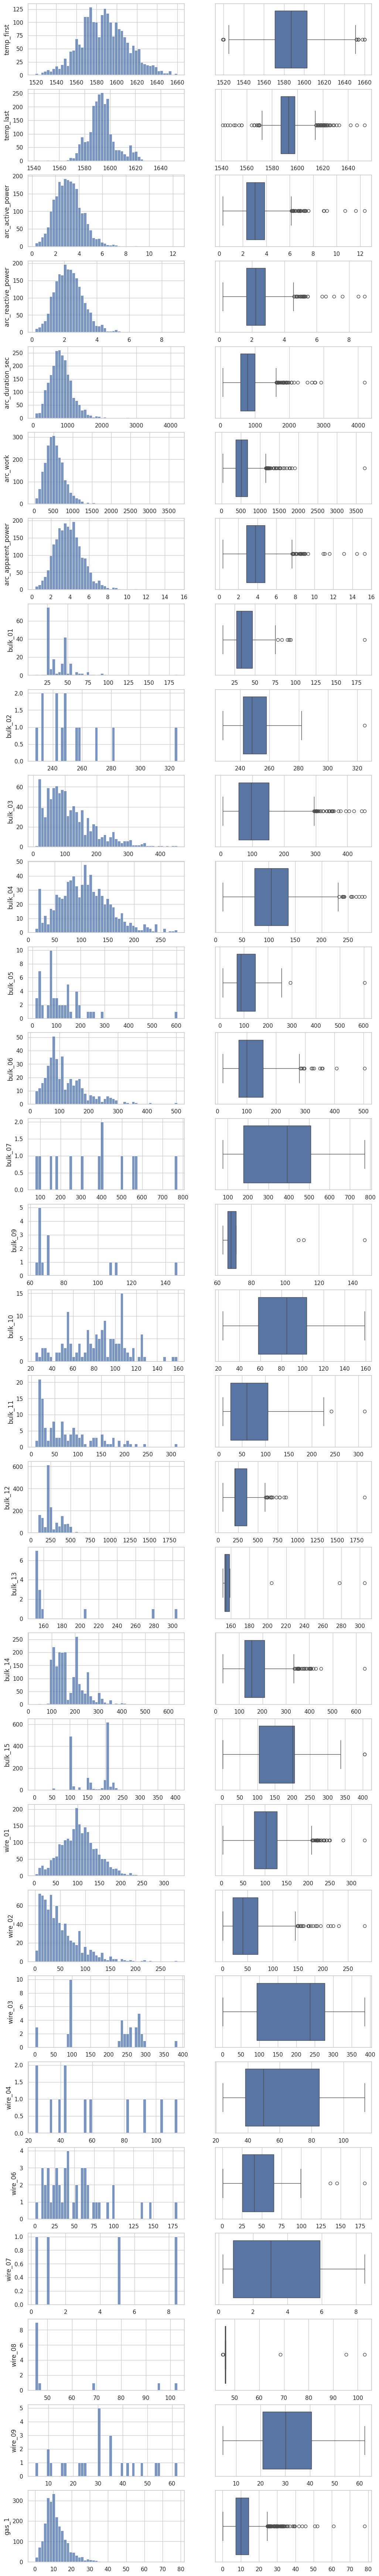

In [41]:
plot_num_cont(data_all_nans)

- Распределение температуры выглядит как нормальное
- Распределение изменения температуры - тоже, с модой чуть выше нуля
- Остальные параметры - artificial, явных выбросов больше не наблюдается
- Порядки значений сильно разнятся, нормализация будет необходима.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Идея понятна, хорошо. По сути, данные, в основном - ненормально распределены)</p>
</div>

### Корреляция между признаками

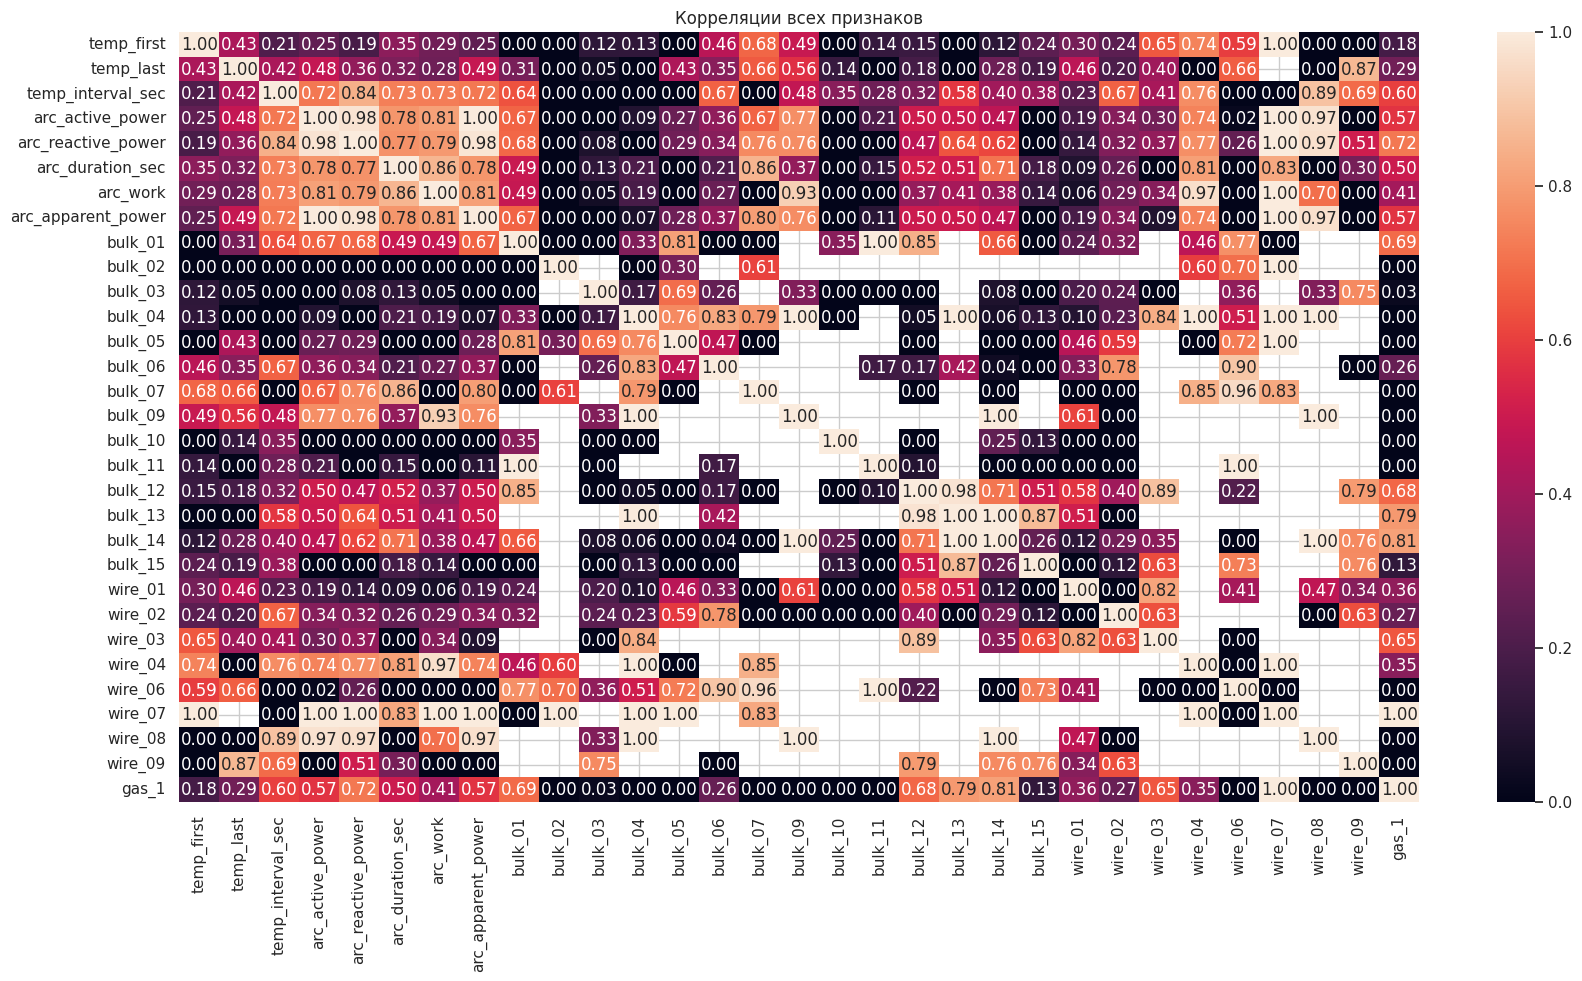

In [58]:
num_col_list = data_all_nans.select_dtypes(include='number').columns.to_list()
corr_matrix = data_all_nans.phik_matrix(interval_cols=num_col_list)
#corr_matrix = data_all_nans[num_col_list].corr()
plt.figure(figsize=(20, 10))
plot = sns.heatmap(corr_matrix, annot=True, fmt='.2f');
plot.set_title('Корреляции всех признаков');

- Нет каких-то параметров, сильно коррелирующих с температурой.
- По нескольким параметрам наблюдается мультиколлинеарность. Есть смысл убрать из них те, в которых больше всего пропусков.

<div class="alert alert-danger" style="border-color: darkred; border-radius: 5px">
    <p><u><b>❌ КОММЕНТАРИЙ РЕВЬЮЕРА</b></u></p>
Есть графический анализ, отлично!!!! И с мультиколлинеарностью надо точно бороться. ЗАМЕЧУ один важный момент по корреляционному аализу. Функция corr() по умолчанию использует метод Пирсона. НО он исключетельно к нормально распределённым данным подходит. У нас же данные ( и графический анализ у тебя это и показал) ненормально распределны. Значет нужен иной метод корреляционного анализа. А именно метод Спирмена или Кендала. Посмотри этот момент ещё раз!!

ищем корреляции больше 0.9

In [59]:
corr_matrix[corr_matrix[corr_matrix > 0.9].count() > 1][corr_matrix > 0.9]

,temp_first,temp_last,temp_interval_sec,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_04,wire_06,wire_07,wire_08,wire_09,gas_1
temp_first,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
arc_active_power,NaN,NaN,NaN,1.000000,0.977693,NaN,NaN,0.999815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.972759,NaN,NaN
arc_reactive_power,NaN,NaN,NaN,0.977693,1.000000,NaN,NaN,0.984096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.970875,NaN,NaN
arc_work,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.926944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.966702,NaN,1.0,NaN,NaN,NaN
arc_apparent_power,NaN,NaN,NaN,0.999815,0.984096,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.970877,NaN,NaN
bulk_01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bulk_02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
bulk_04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.0,1.000000,NaN,NaN
bulk_05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
bulk_07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.956136,NaN,NaN,NaN,NaN


Еще раз выведем info data_all_nans, чтобы удобнее было выбирать параметры для удаления

In [44]:
data_all_nans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2324 entries, 1 to 2499
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp_first          2324 non-null   float64
 1   temp_last           2324 non-null   float64
 2   temp_interval_sec   2324 non-null   int32  
 3   arc_active_power    2324 non-null   float64
 4   arc_reactive_power  2324 non-null   float64
 5   arc_duration_sec    2324 non-null   float64
 6   arc_work            2324 non-null   float64
 7   arc_apparent_power  2324 non-null   float64
 8   bulk_01             199 non-null    float64
 9   bulk_02             13 non-null     float64
 10  bulk_03             958 non-null    float64
 11  bulk_04             811 non-null    float64
 12  bulk_05             53 non-null     float64
 13  bulk_06             437 non-null    float64
 14  bulk_07             13 non-null     float64
 15  bulk_09             13 non-null     float64
 16  bulk_10    

flds_to_drop - список параметров, которые удалим перед обучением

In [45]:
flds_to_drop = []
# arc_active_power vs arc_reactive_power
flds_to_drop.append('arc_reactive_power')
# arc_active_power vs arc_apparent_power
flds_to_drop.append('arc_apparent_power')
# bulk_04 (11046) vs wire_04 (345) and wire_08 (225)
flds_to_drop.append('wire_04')
flds_to_drop.append('wire_08')
# bulk_06 (6903) vs wire_09 (313)
flds_to_drop.append('wire_09')
# bulk_07 (438) vs bulk_12 (33598) and bulk_14 (45504) and wire_02 (12738)
flds_to_drop.append('bulk_07')
# wire_09 (313) vs bulk_06 (6903)
flds_to_drop.append('wire_09')
flds_to_drop

['arc_reactive_power',
 'arc_apparent_power',
 'wire_04',
 'wire_08',
 'wire_09',
 'bulk_07',
 'wire_09']

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>понял, хорошо.</p>
</div>

<div class="alert alert-danger" style="border-color: darkred; border-radius: 5px">
    <p><u><b>❌ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Резёмиирую по итоговому датасету: Надо оперировать понятием "объект моделирования". У нас это ковш в целом, НЕ ПРОСТО СТРОКА И итоговый датасет долженбыть организован%: одна строка - один ковш. В итоге, у нас должно быть не более 2300 строк. 
        
Ну и целевая у нас - последняя температура по партии. Фактором можно взять - ТОЛЬКО первую, как начальное состояние объекта.  (НА встрече подробно говорили об этом. Можно по записи ещё раз глянуть).<br>
        
        
Поэтому, моделирование далее не буду подробно глядеть)
</div>

## Обучение
Сделаем класс для удобства изучения моделей. Он поделит выборку на обучающую и тестовую, будет создавать и обучать модели нескольких типов и отображать анализ результатов на обучающей и тестовой выборке.

Сделать reset_index понадобилось для дальнейшего сопоставления спрогнозированных значений и исходных данных.

PolynomialFeatures добавит нелинейности

In [46]:
class Learn:
	rnd_seed_		= 61026
	test_fraction_	= 0.25
	target_fld_		= 'temp_last'
	drop_fld_		= [target_fld_] + flds_to_drop

	def __init__(self, df):
		df_wt_key = df.reset_index(drop=True)
		x = df_wt_key.drop(columns=Learn.drop_fld_)
		y = df_wt_key[Learn.target_fld_]
		self.x_train_, self.x_test_, self.y_train_, self.y_test_ =\
			train_test_split(x, y, test_size=Learn.test_fraction_, random_state=Learn.rnd_seed_)
		self.pipe_lin_reg_ = None
		self.pipe_cat_boost_ = None
		self.pipe_tree_ = None
		self.gradient_boost_ = None

	def linear_regression(self):
		if self.pipe_lin_reg_ is None:
			self.pipe_lin_reg_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					optuna.integration.OptunaSearchCV(
						LinearRegression(),
						{},
						cv=5,
						random_state=Learn.rnd_seed_,
						n_trials=1
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.pipe_lin_reg_

	def cat_boost(self):
		if self.pipe_cat_boost_ is None:
			self.pipe_cat_boost_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					optuna.integration.OptunaSearchCV(
						CatBoostRegressor(
							loss_function='MAE',
							random_seed=Learn.rnd_seed_
						),
						{},
						cv=5,
						random_state=Learn.rnd_seed_,
						n_trials=1
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.pipe_cat_boost_

	def decision_tree(self):
		if self.pipe_tree_ is None:
			self.pipe_tree_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					optuna.integration.OptunaSearchCV(
						DecisionTreeRegressor(random_state=Learn.rnd_seed_),
						{
							'max_depth': optuna.distributions.IntDistribution(1, 20, step=1)
						},
						cv=5,
						random_state=Learn.rnd_seed_
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.pipe_tree_

	def gradient_boost(self):
		if self.gradient_boost_ is None:
			self.gradient_boost_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					GradientBoostingRegressor(
						loss='absolute_error',
						random_state=Learn.rnd_seed_
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.gradient_boost_

	def explore(self, estimator, x, y, label):
		print(f'{label} R2: {estimator.score(x, y):.04f}')
		y_pred = estimator.predict(x)
		print(f'{label} MAE: {mean_absolute_error(y, y_pred):.04f}')
		y_df = pd.DataFrame({'y_true': y, 'y_pred': y_pred})
		y_df.loc[:, 'y_error'] = y_df['y_pred'] - y_df['y_true']

		fig, axs = plt.subplots(2, 2, figsize=(15, 10))
		sns.scatterplot(y_df, x='y_true', y='y_pred', ax=axs[0, 0]).set_title(f'{label}. Предсказания в пространстве таргета');
		sns.scatterplot(y_df, x='y_true', y='y_error', ax=axs[0, 1]).set_title(f'{label}. Ошибки в пространстве таргета');
		sns.histplot(y_df, x='y_error', ax=axs[1, 0]).set_title(f'{label}. Гистограмма ошибок');
		sns.boxplot(y_df, x='y_error', ax=axs[1, 1]).set_title(f'{label}. Ящик ошибок');

	def explore_train(self, estimator, label):
		self.explore(estimator, self.x_train_, self.y_train_, label + '.train')

	def explore_test(self, estimator, label):
		self.explore(estimator, self.x_test_, self.y_test_, label + '.test')

learn = Learn(data_all)

/tmp/ipykernel_2028133/334131464.py:25: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna.integration.OptunaSearchCV(
[I 2025-10-14 08:44:55,583] A new study created in memory with name: no-name-206c4103-4dfa-451c-8593-04bbb13f270f


[I 2025-10-14 08:44:55,928] Trial 0 finished with value: -279.2020927875561 and parameters: {}. Best is trial 0 with value: -279.2020927875561.


LinearRegression.train R2: 0.6572
LinearRegression.train MAE: 4.9249


/tmp/ipykernel_2028133/334131464.py:43: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna.integration.OptunaSearchCV(
[I 2025-10-14 08:44:56,313] A new study created in memory with name: no-name-7fd27af8-75d1-4b53-8a02-2fbd5dc9ee4a


0:	learn: 8.1046834	total: 67.3ms	remaining: 1m 7s
1:	learn: 8.0417404	total: 87ms	remaining: 43.4s
2:	learn: 7.9794154	total: 105ms	remaining: 34.7s
3:	learn: 7.9229807	total: 123ms	remaining: 30.5s
4:	learn: 7.8540205	total: 140ms	remaining: 27.9s
5:	learn: 7.7932233	total: 158ms	remaining: 26.2s
6:	learn: 7.7346126	total: 176ms	remaining: 25s
7:	learn: 7.6897178	total: 194ms	remaining: 24s
8:	learn: 7.6486992	total: 214ms	remaining: 23.6s
9:	learn: 7.5978029	total: 233ms	remaining: 23s
10:	learn: 7.5358793	total: 251ms	remaining: 22.6s
11:	learn: 7.4878443	total: 270ms	remaining: 22.3s
12:	learn: 7.4493438	total: 289ms	remaining: 22s
13:	learn: 7.4010905	total: 309ms	remaining: 21.8s
14:	learn: 7.3516285	total: 329ms	remaining: 21.6s
15:	learn: 7.3045242	total: 348ms	remaining: 21.4s
16:	learn: 7.2665671	total: 368ms	remaining: 21.3s
17:	learn: 7.2220898	total: 386ms	remaining: 21.1s
18:	learn: 7.1662092	total: 404ms	remaining: 20.9s
19:	learn: 7.1203560	total: 422ms	remaining: 20.7

[I 2025-10-14 08:47:03,440] Trial 0 finished with value: 0.42280554273086607 and parameters: {}. Best is trial 0 with value: 0.42280554273086607.


0:	learn: 8.0227414	total: 19.1ms	remaining: 19.1s
1:	learn: 7.9714307	total: 37.9ms	remaining: 18.9s
2:	learn: 7.9028000	total: 57ms	remaining: 18.9s
3:	learn: 7.8452132	total: 78ms	remaining: 19.4s
4:	learn: 7.7766206	total: 96.8ms	remaining: 19.3s
5:	learn: 7.7305449	total: 120ms	remaining: 19.8s
6:	learn: 7.6683267	total: 139ms	remaining: 19.7s
7:	learn: 7.6225916	total: 160ms	remaining: 19.9s
8:	learn: 7.5678205	total: 180ms	remaining: 19.8s
9:	learn: 7.5257842	total: 201ms	remaining: 19.9s
10:	learn: 7.4810246	total: 221ms	remaining: 19.9s
11:	learn: 7.4383135	total: 240ms	remaining: 19.8s
12:	learn: 7.3971426	total: 261ms	remaining: 19.8s
13:	learn: 7.3523719	total: 281ms	remaining: 19.8s
14:	learn: 7.3066975	total: 300ms	remaining: 19.7s
15:	learn: 7.2665357	total: 322ms	remaining: 19.8s
16:	learn: 7.2212465	total: 342ms	remaining: 19.8s
17:	learn: 7.1782785	total: 362ms	remaining: 19.8s
18:	learn: 7.1447719	total: 381ms	remaining: 19.7s
19:	learn: 7.0996273	total: 400ms	remain

/tmp/ipykernel_2028133/334131464.py:64: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna.integration.OptunaSearchCV(
[I 2025-10-14 08:47:29,809] A new study created in memory with name: no-name-04e2291e-a2f4-4ba1-a693-3f7d458ec94c
[I 2025-10-14 08:47:30,090] Trial 0 finished with value: 0.15133122947602518 and parameters: {'max_depth': 2}. Best is trial 0 with value: 0.15133122947602518.
[I 2025-10-14 08:47:32,564] Trial 1 finished with value: -0.12867603478993522 and parameters: {'max_depth': 17}. Best is trial 0 with value: 0.15133122947602518.
[I 2025-10-14 08:47:33,658] Trial 2 finished with value: -0.01590323249554233 and parameters: {'max_depth': 9}. Best is trial 0 with value: 0.15133122947602518.
[I 2025-10-14 08:47:34,730] Trial 3 finished with value: 0.051789955319799574 and parameters: {'max_depth': 1}. Best is trial 0 with value: 0.15133122947602518.
[I 2025-10-14 08:47:36,046] Trial 4 finished wi

DecisionTreeRegressor.train R2: 0.5760
DecisionTreeRegressor.train MAE: 5.4401
GradientBoostingRegressor.train R2: 0.5988
GradientBoostingRegressor.train MAE: 4.7023


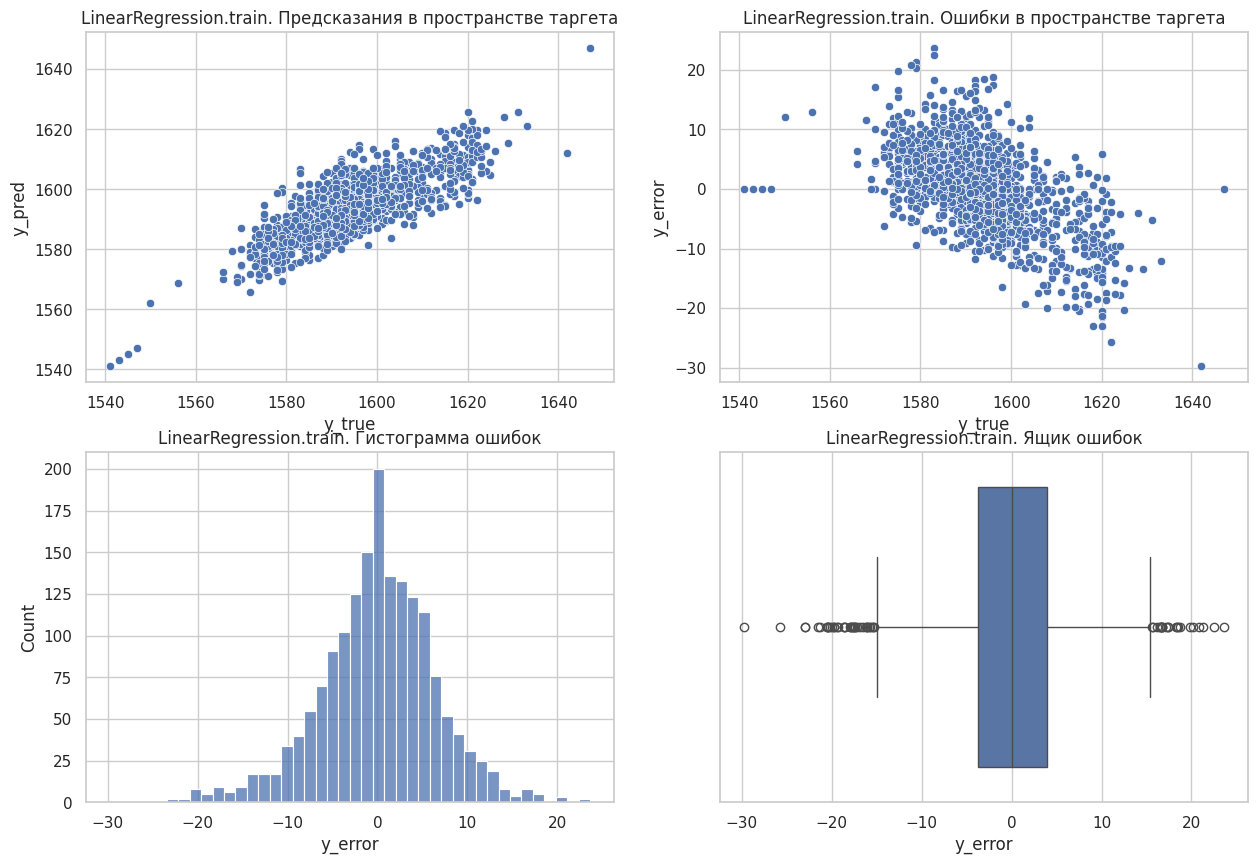

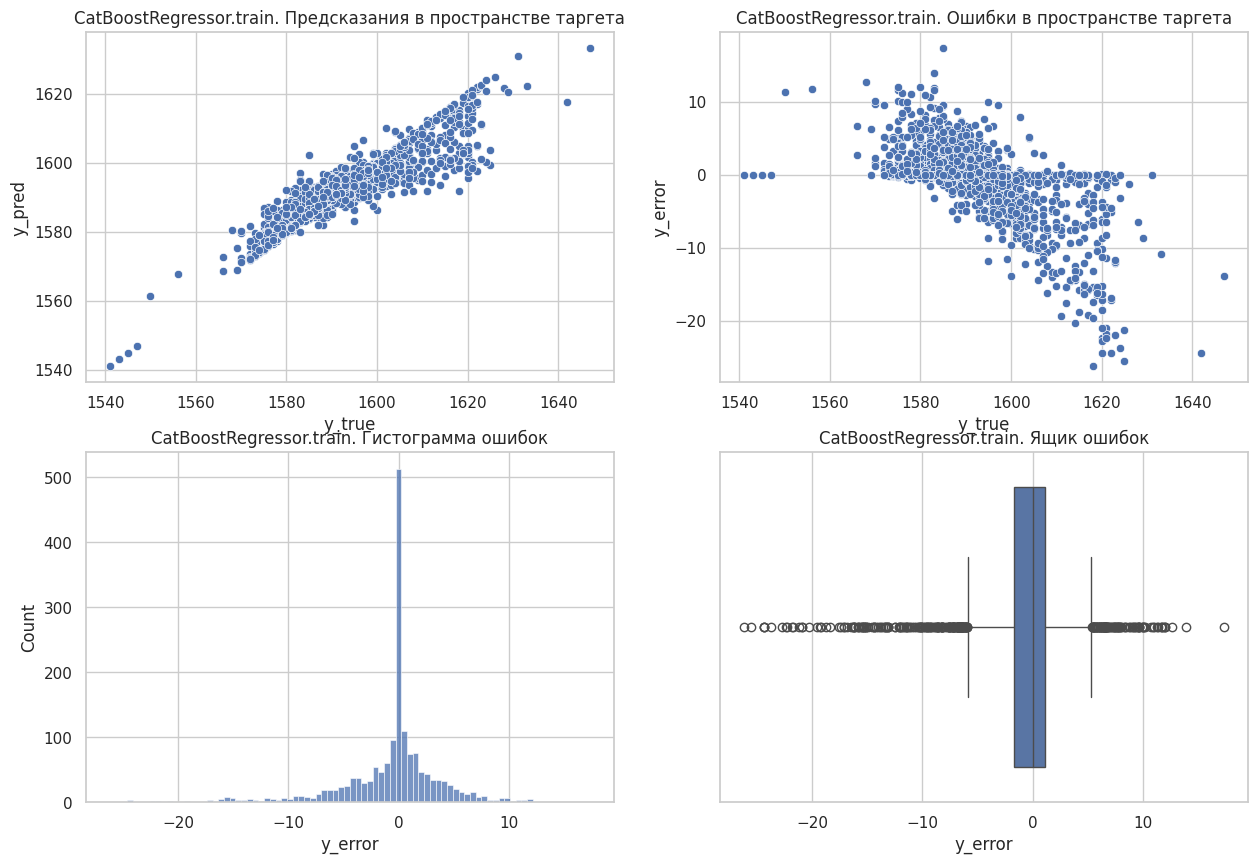

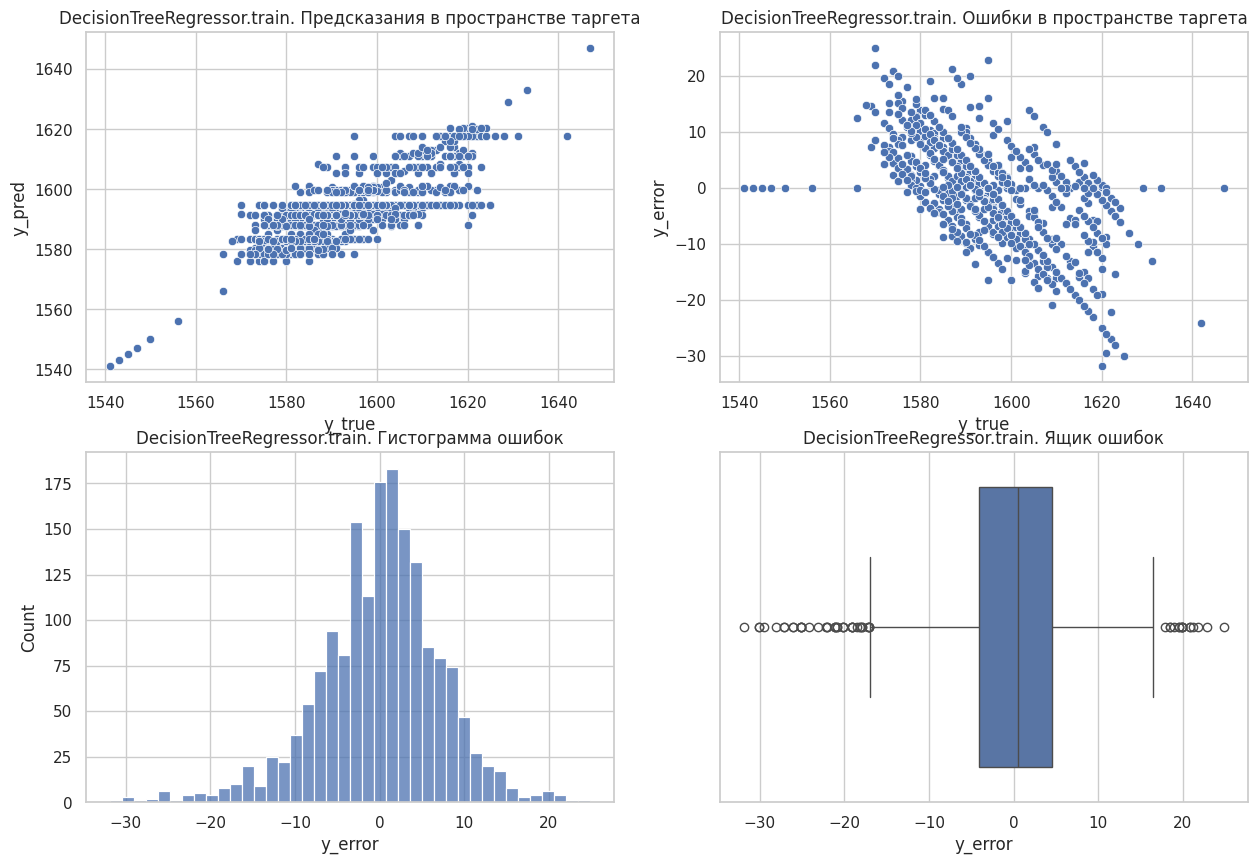

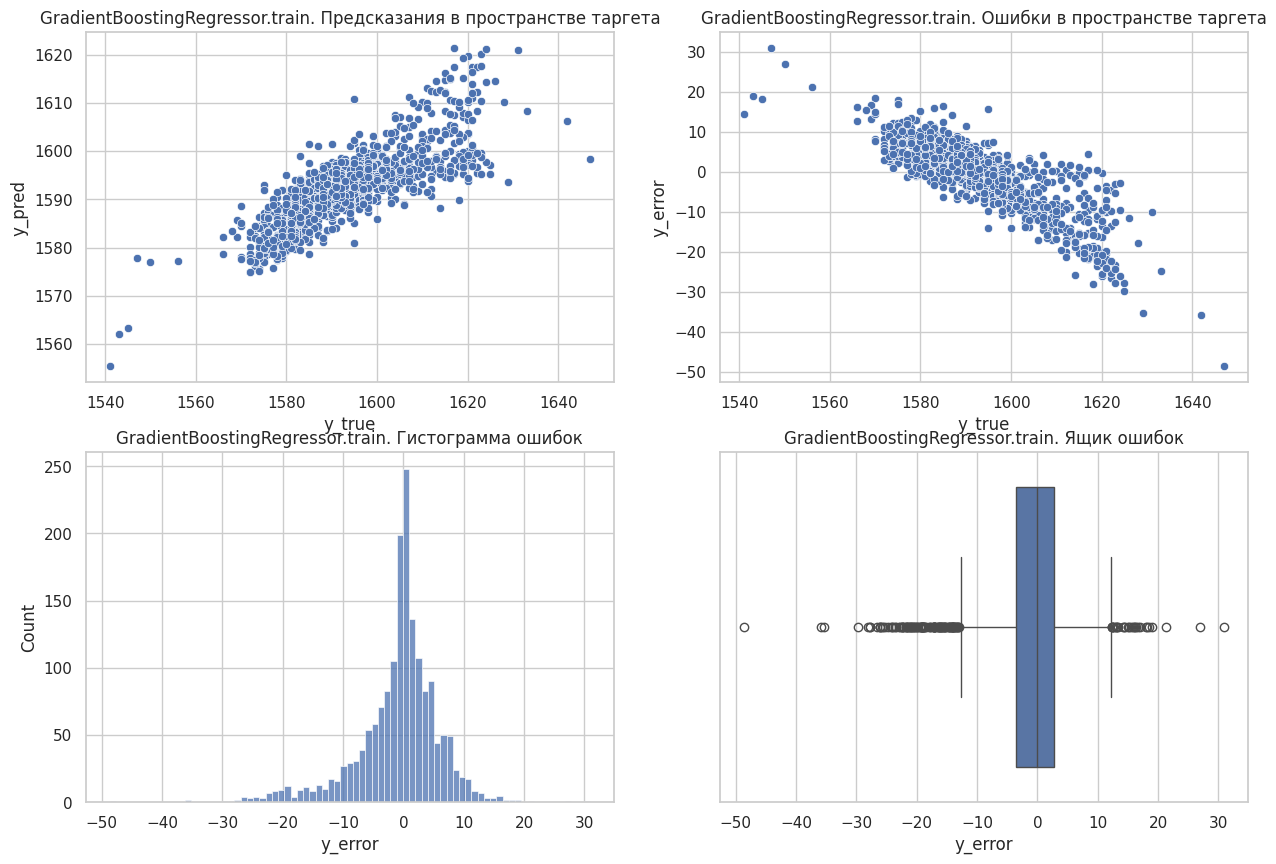

In [47]:
learn.explore_train(learn.linear_regression(), 'LinearRegression')
learn.explore_train(learn.cat_boost(), 'CatBoostRegressor')
learn.explore_train(learn.decision_tree(), 'DecisionTreeRegressor')
learn.explore_train(learn.gradient_boost(), 'GradientBoostingRegressor')


- Облака предсказаний выглядят ожидаемо. Кроме DecisionTreeRegressor - у него есть линия точных попаданий.
- У разброса ошибок есть наклон вниз - при повышении температуры ошибки меньше, чем при понижении.
- Гистограммы ошибок хорошие. Симметричны относительно нуля, выглядят как нормальное распределение.

In [48]:
data_all[Learn.target_fld_].describe()

count    2324.000000
mean     1593.372633
std        11.207457
min      1541.000000
25%      1587.000000
50%      1593.000000
75%      1598.000000
max      1653.000000
Name: temp_last, dtype: float64

- У нас IQR таргета 17 градусов С - это чтобы лучше представлять масштаб ошибки (3-7 град)
- DecisionTreeRegressor сильно выделяется по точности. И часть прогнозов прямо подозрительно точны. Хорошо бы понять, почему, и нет ли где-то ошибки.

Посмотрим, каких значения были у входных параметров там, где ошибка DecisionTreeRegressor близка к 0. Может, там все 0 или какие-то аномалии?

In [49]:
y_df = pd.DataFrame({'y_true': learn.y_train_, 'y_pred': learn.decision_tree().predict(learn.x_train_)})
y_df.loc[:, 'y_error'] = y_df['y_pred'] - y_df['y_true']
y_df = y_df.merge(learn.x_train_, left_index=True, right_index=True, how='inner')
y_df.query('abs(y_error) < 0.1')

,y_true,y_pred,y_error,temp_first,temp_interval_sec,arc_active_power,arc_duration_sec,arc_work,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_06,wire_07,gas_1
361,1606.0,1606.000000,0.000000,1556.0,3571,5.494361,1649.0,1053.009590,0.0,0.0,116.0,0.0,0.0,0.0,0.0,0.0,0.0,411.0,0.0,275.0,152.0,121.305594,46.174957,0.000000,0.000000,0.000000,20.289447
248,1600.0,1600.000000,0.000000,1532.0,3169,4.248512,1807.0,850.044250,0.0,0.0,126.0,0.0,0.0,0.0,63.0,0.0,0.0,108.0,0.0,263.0,0.0,160.174557,76.236166,0.000000,0.000000,0.000000,60.935689
1969,1541.0,1541.000000,0.000000,1639.0,21331,10.706804,2739.0,1761.888070,63.0,242.0,0.0,98.0,94.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.051040,0.000000,93.213127,63.045845,1.053936,45.638999
1311,1599.0,1599.000000,0.000000,1604.0,3099,4.043988,1156.0,864.428276,0.0,0.0,0.0,0.0,0.0,150.0,0.0,0.0,0.0,281.0,0.0,217.0,159.0,73.148399,150.407913,0.000000,0.000000,0.000000,7.858785
31,1613.0,1613.000000,0.000000,1602.0,3478,1.737635,1002.0,461.333513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,408.0,0.0,257.0,154.0,105.225121,0.000000,0.000000,0.000000,0.000000,14.881404
96,1547.0,1547.000000,0.000000,1635.0,6992,4.161833,725.0,552.638355,78.0,232.0,0.0,21.0,112.0,0.0,0.0,0.0,67.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,64.212723,0.000000,22.201580
747,1603.0,1603.000000,0.000000,1548.0,3946,6.099306,2247.0,1592.684208,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,0.0,109.0,0.0,354.0,0.0,29.250000,85.141678,0.000000,0.000000,0.000000,19.856740
1821,1550.0,1550.000000,0.000000,1530.0,3046,2.823011,826.0,532.713795,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.221120,0.000000,0.000000,0.000000,0.000000,10.406837
46,1588.0,1588.093333,0.093333,1626.0,3574,0.994742,126.0,125.337492,0.0,0.0,0.0,0.0,0.0,157.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.312000,0.000000,0.000000,0.000000,0.000000,10.441228
406,1611.0,1610.961538,-0.038462,1615.0,4648,4.068584,1331.0,953.308197,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,309.0,0.0,203.0,158.0,221.317184,14.024400,0.000000,0.000000,0.000000,16.822410


- вроде бы нет. ничего в глаза не бросается

Подсмотрим результаты тестовой выборки для нее. Может, там все значительно хуже:

LinearRegression.test R2: 0.3585
LinearRegression.test MAE: 6.2303
CatBoostRegressor.test R2: 0.4292
CatBoostRegressor.test MAE: 5.8750
DecisionTreeRegressor.test R2: 0.0567
DecisionTreeRegressor.test MAE: 7.2783
GradientBoostingRegressor.test R2: 0.4140
GradientBoostingRegressor.test MAE: 5.9465


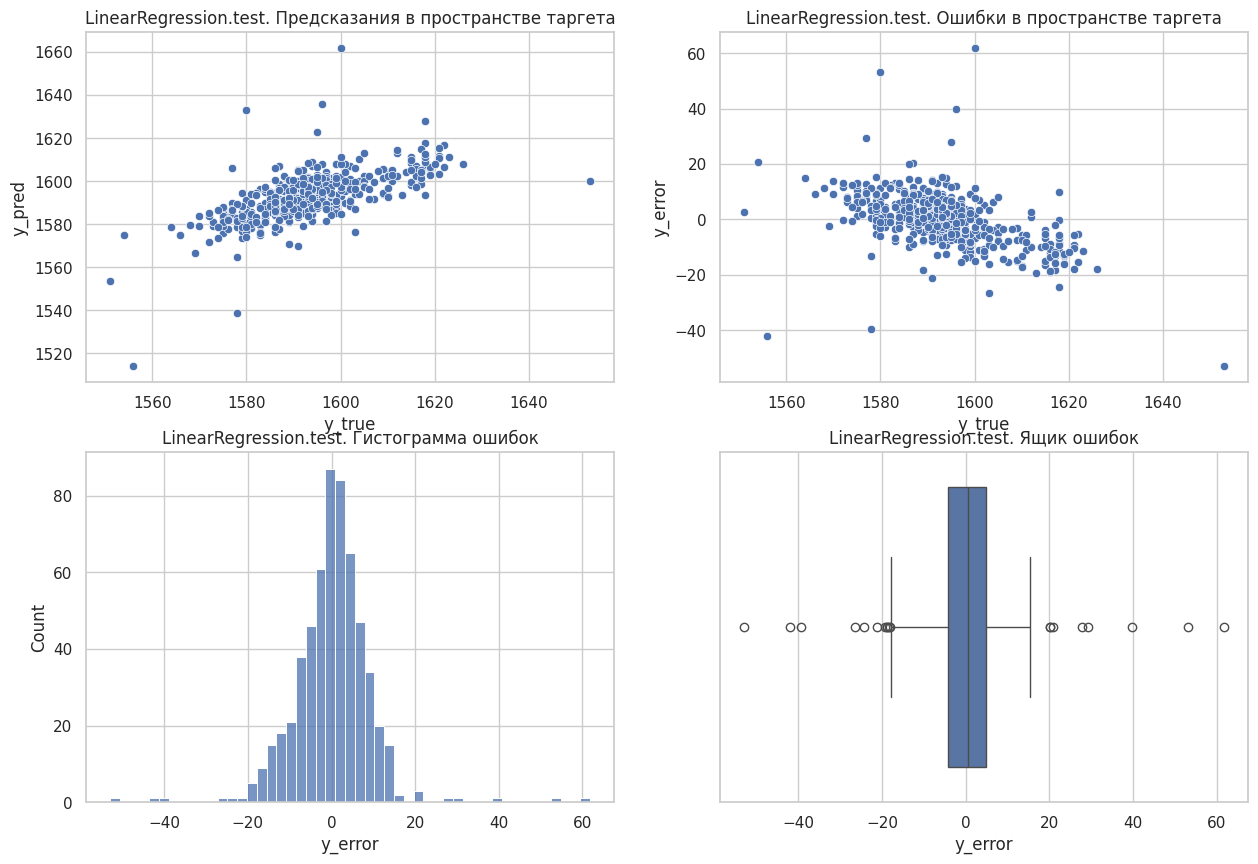

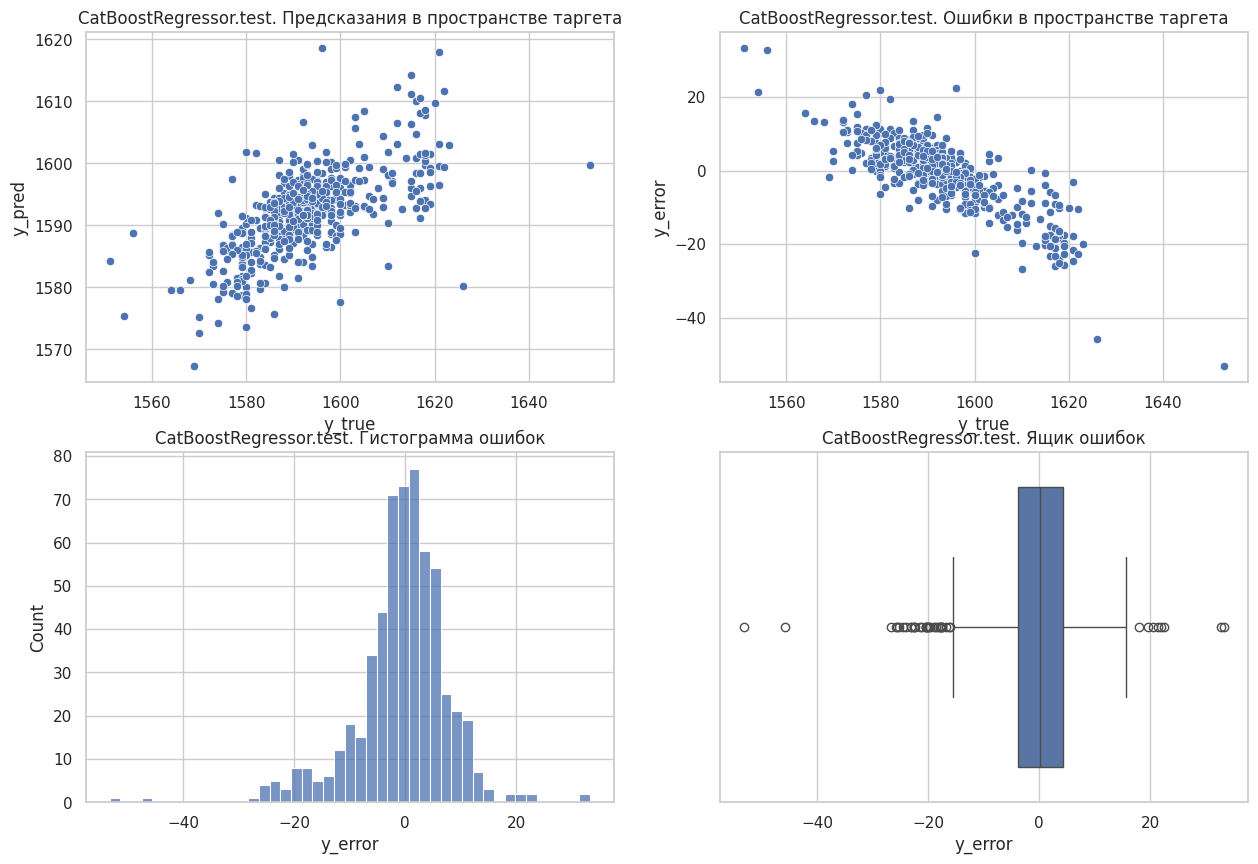

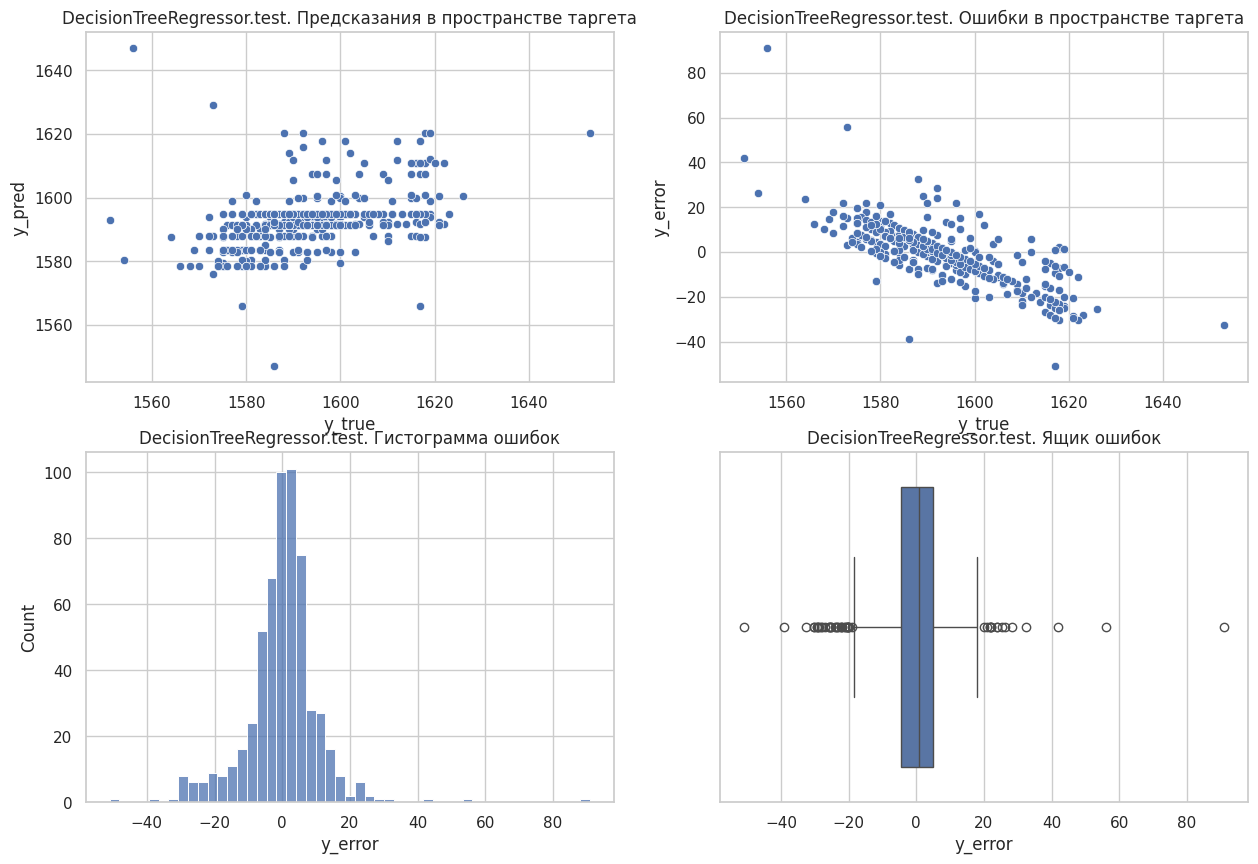

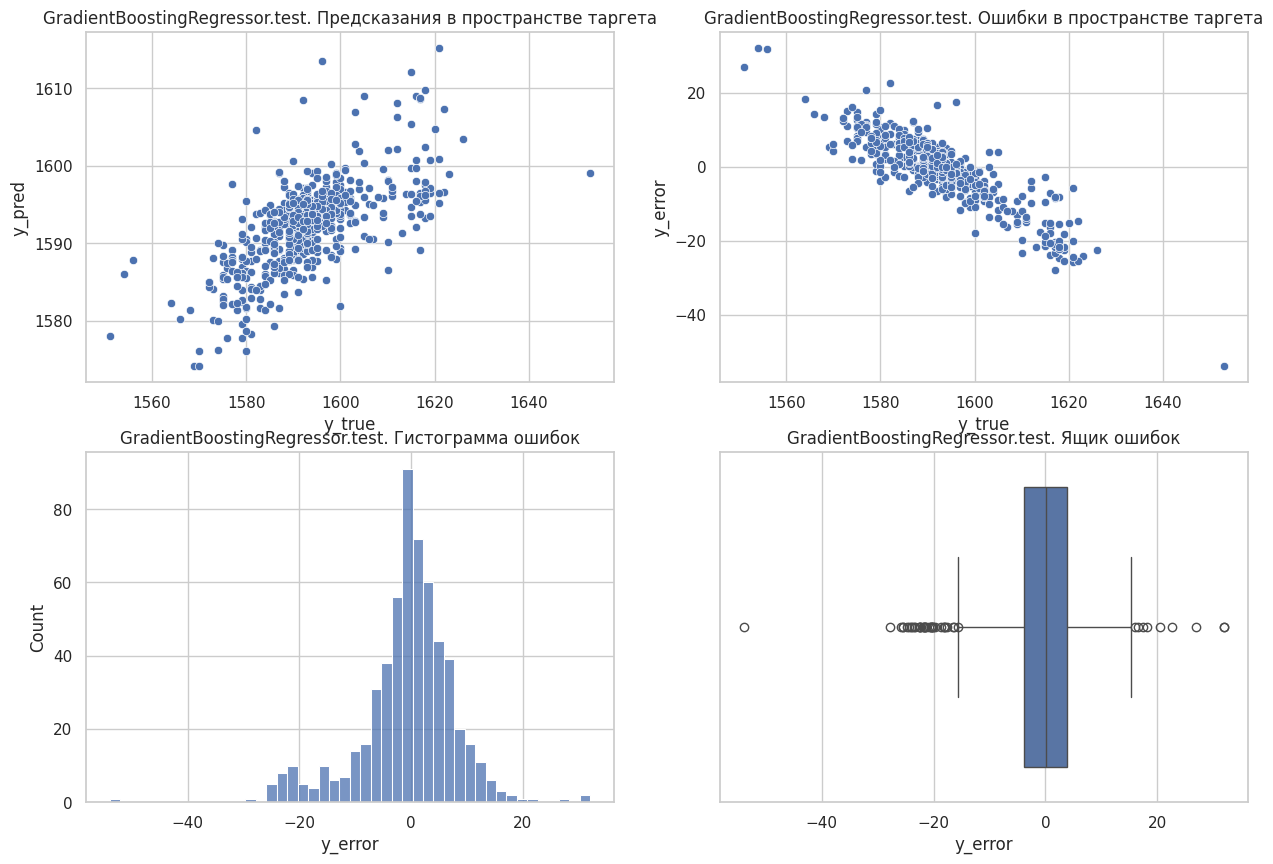

In [56]:
learn.explore_test(learn.linear_regression(), 'LinearRegression')
learn.explore_test(learn.cat_boost(), 'CatBoostRegressor')
learn.explore_test(learn.decision_tree(), 'DecisionTreeRegressor')
learn.explore_test(learn.gradient_boost(), 'GradientBoostingRegressor')

- тоже неплохо относительно остальных. хм

Подсмотрим параметры кэтбуста, чтобы сориентироваться, в каких границах их тюнить.

Key CatBoostRegressor parameters to fine-tune include iterations,
- learning_rate = 0.03 - Used for reducing the gradient step
- depth = 6 - Depth of the trees
- l2_leaf_reg = 3 - Coefficient at the L2 regularization term of the cost function
- subsample = 0.8 - Sample rate for bagging
- rsm = 1 - Random subspace method. The percentage of features to use at each split selection, when features are selected over again at random
- border_count = 254 - The number of splits for numerical features. Allowed values are integers from 1 to 65535 inclusively

 Tuning these values helps optimize the model's performance by adjusting the number of trees, the step size of each tree, the complexity of the trees, and how features are sampled during training.

In [51]:
learn.cat_boost().named_steps['estimator'].best_estimator_.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'MAE',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Exact',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': True,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'random_seed': 61026,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function': 'MAE',
 'lea

## Важность признаков

Собираем вместе имена признаков и значения их важности

Для наглядности отсечем только самые важные. Статистика поможет выбрать порог

In [52]:
feature_importances_dt = pd.DataFrame(
	{
		'name': learn.decision_tree().named_steps['poly'].get_feature_names_out(input_features=learn.x_train_.columns),
		'importance': learn.decision_tree().named_steps['estimator'].best_estimator_.feature_importances_
	}
)
display(feature_importances_dt.describe())

,importance
count,325.000000
mean,0.003077
std,0.013981
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.143296


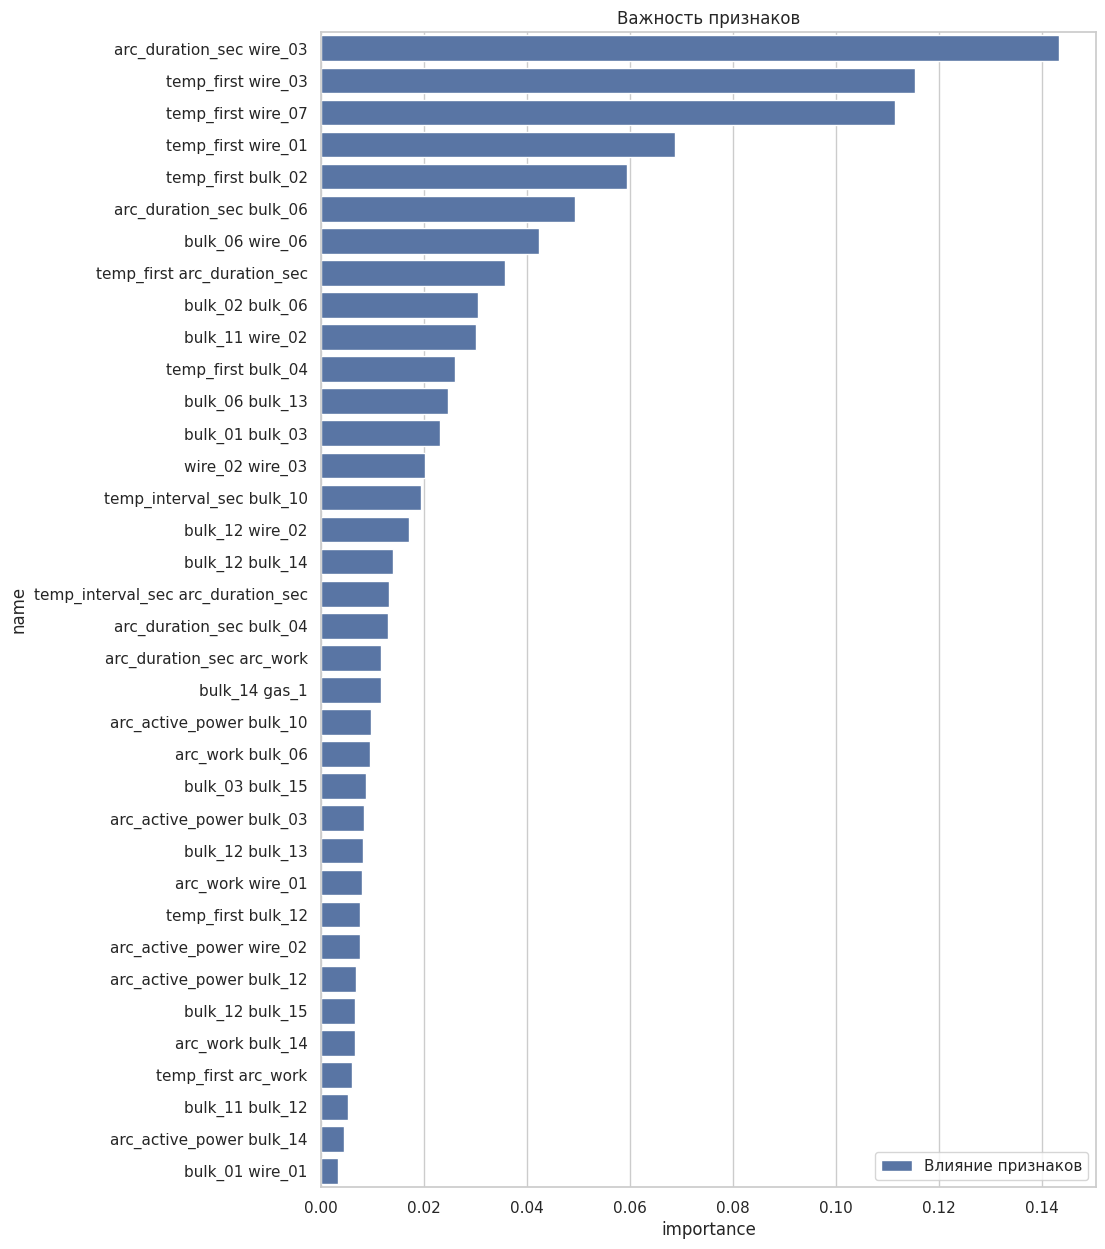

In [53]:
feature_importances_dt.sort_values(by='importance', ascending=False)
fig, axs = plt.subplots(1, 1, figsize=(10, 15))
sns.barplot(
	data=feature_importances_dt.query('importance > 0.003').sort_values(by='importance', ascending=False),
	x="importance", y="name", label="Влияние признаков", orient='h').set_title('Важность признаков');

- Предыдущая температура объяснимо оказывает самое сильное влиянние на результат
- Дальше идут нелинейные комбинацмм предыдущей температуры и различных добавок
- Кроме температуры линейных параметров среди самых важных не встретилось
- Очень странно, что нет нагрева - это совсем неожиданно

Посмотрим на всякий случай важности признаков во второй по точности модели - catboost

,importance
count,325.000000
mean,0.307692
std,0.371407
min,0.000000
25%,0.078547
50%,0.201245
75%,0.382255
max,2.516042


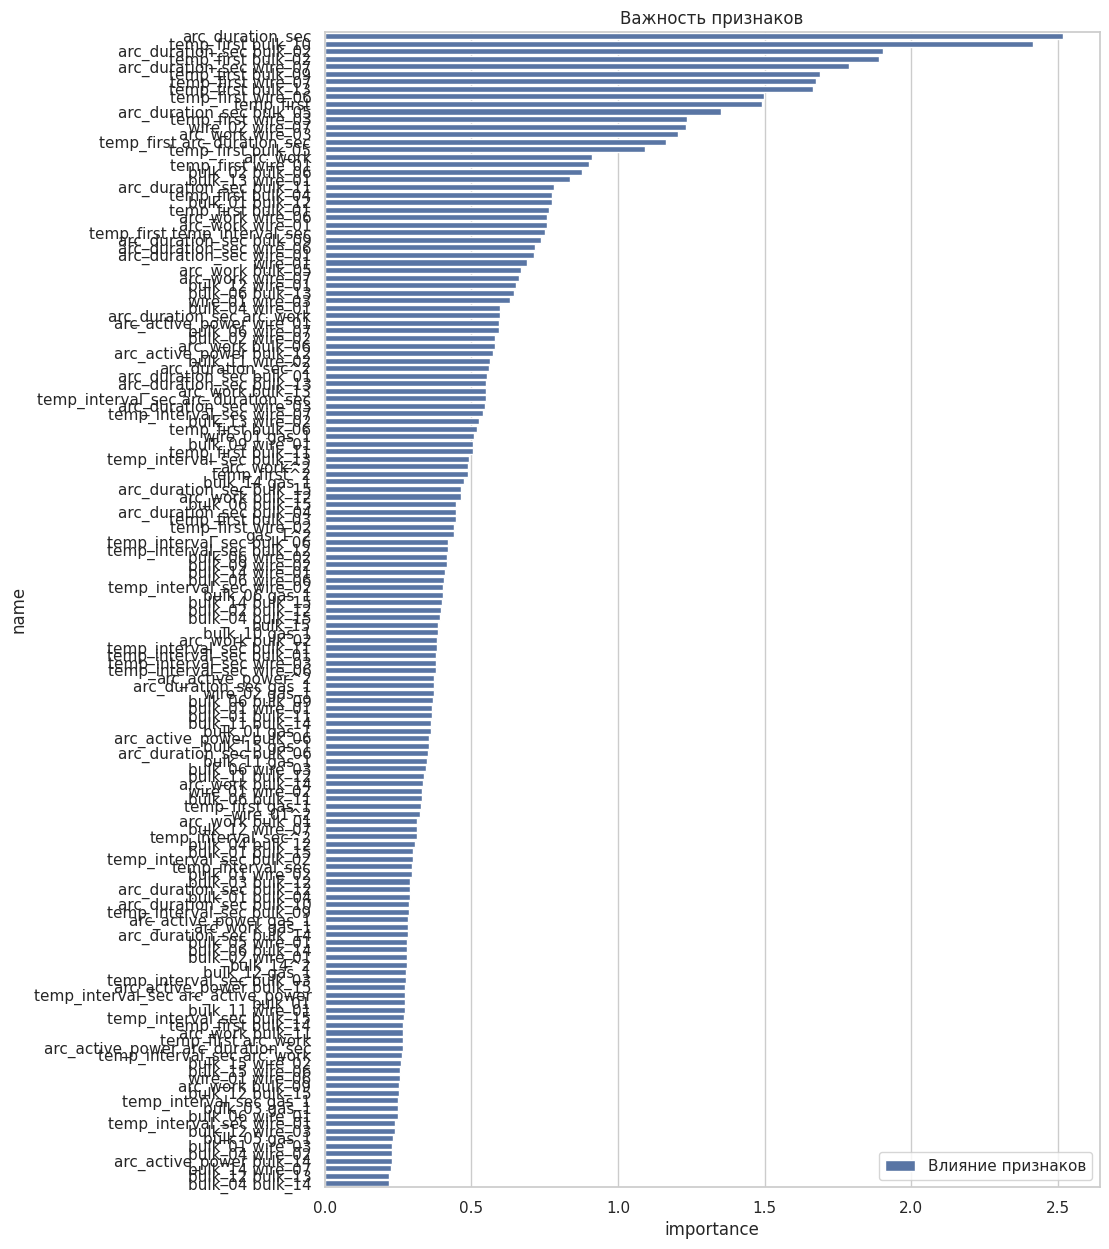

In [54]:
feature_importances_cb = pd.DataFrame(
	{
		'name': learn.cat_boost().named_steps['poly'].get_feature_names_out(input_features=learn.x_train_.columns),
		'importance': learn.cat_boost().named_steps['estimator'].best_estimator_.feature_importances_
	}
)
display(feature_importances_cb.describe())
feature_importances_cb.sort_values(by='importance', ascending=False)
fig, axs = plt.subplots(1, 1, figsize=(10, 15))
sns.barplot(
	data=feature_importances_cb.query('importance > 0.22').sort_values(by='importance', ascending=False),
	x="importance", y="name", label="Влияние признаков", orient='h').set_title('Важность признаков');

- Один раз с не самым значительным весом появилась temp_prev * arc_duration, а в остальном тоже нагрев не оказывает влияние на результат по версии модели. Вряд ли это сназчит, что нагревать не надо, скорее всего так совпало, что технология процесса построена так, что по другим параметрам изменение температуры считается точнее. Наверное, надо иметь в виду, что если технология изменится даже незначительно, то модель скорее всего перестанет работать, ее надо будет переобучать.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>
Артём, в целом - добротная, сильная работа с кодом. Основные вопросы только по данным и формированию иотговой таблицы для моделирования. На встрече мы её подробно обсудили (можно запись на всякий случай ещё раз глянуть). Там основная идея, что объект моделирования - ковш. И работать надо относительно этой идей. Выше по тексту постарался оставлять подробные аргментации. Посомтри, пожалуйста. Если что - пиши. БУДУ ЖДАТЬ!    
    
</p>
</div>